<h2>House Price Prediction Assignment</h2>

<ul>
    <li>Data Preparation</li>
    <li>Model Building Using linear regression</li>
    <li>Model Building Using Ridge Regression</li>
    <li>Model Building Using Lasso</li>
    <li>Hyperparameter tuning</li>
    <li>Comparing Models</li>
    <li>Conclusion</li>
</ul> 


In [1]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

pd.options.display.width = 1000
# Set the option to display all info columns
pd.set_option('display.max_info_columns', 100)
pd.set_option('display.max_columns', 100)

import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading

In [2]:
df = pd.read_csv('train.csv')

print('######### Data Information #########')
print(df.info())



######### Data Information #########
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    

## 2. Data Cleaning

### 2.a Handling missing values

In [3]:
# Exclude the columns with 80% or more missing values

print(len(df) * 0.80)
print(df['Alley'].isnull().sum())

# Print columns to be excluded
columns_to_exclude = df.columns[df.isnull().sum() >= len(df) * 0.80]
print('\nColumns to be excluded (80% or more missing values):')
print(columns_to_exclude.tolist())

# Exclude the identified columns
df = df.drop(columns=columns_to_exclude)
print('\nData shape after excluding columns with 80% or more missing values:', df.shape)

1168.0
1369

Columns to be excluded (80% or more missing values):
['Alley', 'PoolQC', 'Fence', 'MiscFeature']

Data shape after excluding columns with 80% or more missing values: (1460, 77)


In [4]:
print('\n######### First 5 Rows #########')
print(df.head())


######### First 5 Rows #########
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street LotShape LandContour Utilities LotConfig LandSlope Neighborhood Condition1 Condition2 BldgType HouseStyle  OverallQual  OverallCond  YearBuilt  YearRemodAdd RoofStyle RoofMatl Exterior1st Exterior2nd MasVnrType  MasVnrArea ExterQual ExterCond Foundation BsmtQual BsmtCond BsmtExposure BsmtFinType1  BsmtFinSF1 BsmtFinType2  BsmtFinSF2  BsmtUnfSF  TotalBsmtSF Heating HeatingQC CentralAir Electrical  1stFlrSF  2ndFlrSF  LowQualFinSF  GrLivArea  BsmtFullBath  BsmtHalfBath  FullBath  HalfBath  BedroomAbvGr  KitchenAbvGr KitchenQual  TotRmsAbvGrd Functional  Fireplaces FireplaceQu GarageType  GarageYrBlt GarageFinish  GarageCars  GarageArea GarageQual GarageCond PavedDrive  WoodDeckSF  OpenPorchSF  EnclosedPorch  3SsnPorch  ScreenPorch  PoolArea  MiscVal  MoSold  YrSold SaleType SaleCondition  SalePrice
0   1          60       RL         65.0     8450   Pave      Reg         Lvl    AllPub    Inside      

### 2.b Handling Null Values

In [5]:
# Print all column names with missing values, column type, number of missing values, mode of values, 
# mean of values for numeric columns, count of distinct values in a data frame
missing_info = []
for col in df.columns:
    missing_count = df[col].isnull().sum()
    if missing_count > 0:
        col_type = df[col].dtype
        mode_value = df[col].mode()[0] if not df[col].mode().empty else np.nan
        mean_value = df[col].mean() if pd.api.types.is_numeric_dtype(df[col]) else np.nan
        distinct_count = df[col].nunique()
        missing_info.append({
            'Column': col,
            'Type': col_type,
            'Missing Values': missing_count,
            'Mode': mode_value,
            'Mean': mean_value,
            'Distinct Count': distinct_count
        })

missing_info = pd.DataFrame(missing_info)

print('\nColumns with Missing Values:')
print(missing_info)


Columns with Missing Values:
          Column     Type  Missing Values     Mode         Mean  Distinct Count
0    LotFrontage  float64             259     60.0    70.049958             110
1     MasVnrType   object             872  BrkFace          NaN               3
2     MasVnrArea  float64               8      0.0   103.685262             327
3       BsmtQual   object              37       TA          NaN               4
4       BsmtCond   object              37       TA          NaN               4
5   BsmtExposure   object              38       No          NaN               4
6   BsmtFinType1   object              37      Unf          NaN               6
7   BsmtFinType2   object              38      Unf          NaN               6
8     Electrical   object               1    SBrkr          NaN               5
9    FireplaceQu   object             690       Gd          NaN               5
10    GarageType   object              81   Attchd          NaN               6
11   Garag

In [6]:
# fill missing values for categorical columns with mode and numeric columns with mean
# but for GarageYrBlt fill with mode as it represents year built
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if pd.api.types.is_numeric_dtype(df[col]) and col != 'GarageYrBlt':
            mean_value = df[col].mean()
            df[col] = df[col].fillna(mean_value)
        else:
            mode_value = df[col].mode()[0]
            df[col] = df[col].fillna(mode_value)

print('\n######### Data Information After Handling Missing Values #########')
print(df.info())
print('\n######### Columns with Missing Values After Handling Missing Values #########')
print(df.isnull().sum()[df.isnull().sum() > 0])


######### Data Information After Handling Missing Values #########
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 77 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null

## 3. Data Processing & EDA

### 3.a Analysing Numerical Variables

In [7]:
# List of numnerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols.remove('Id')  # Remove Id column if present

categorial_cols = df.select_dtypes(include=['object']).columns.tolist()

print('\nNumerical Columns,(', len(numerical_cols), '):')
print(numerical_cols)



Numerical Columns,( 37 ):
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']


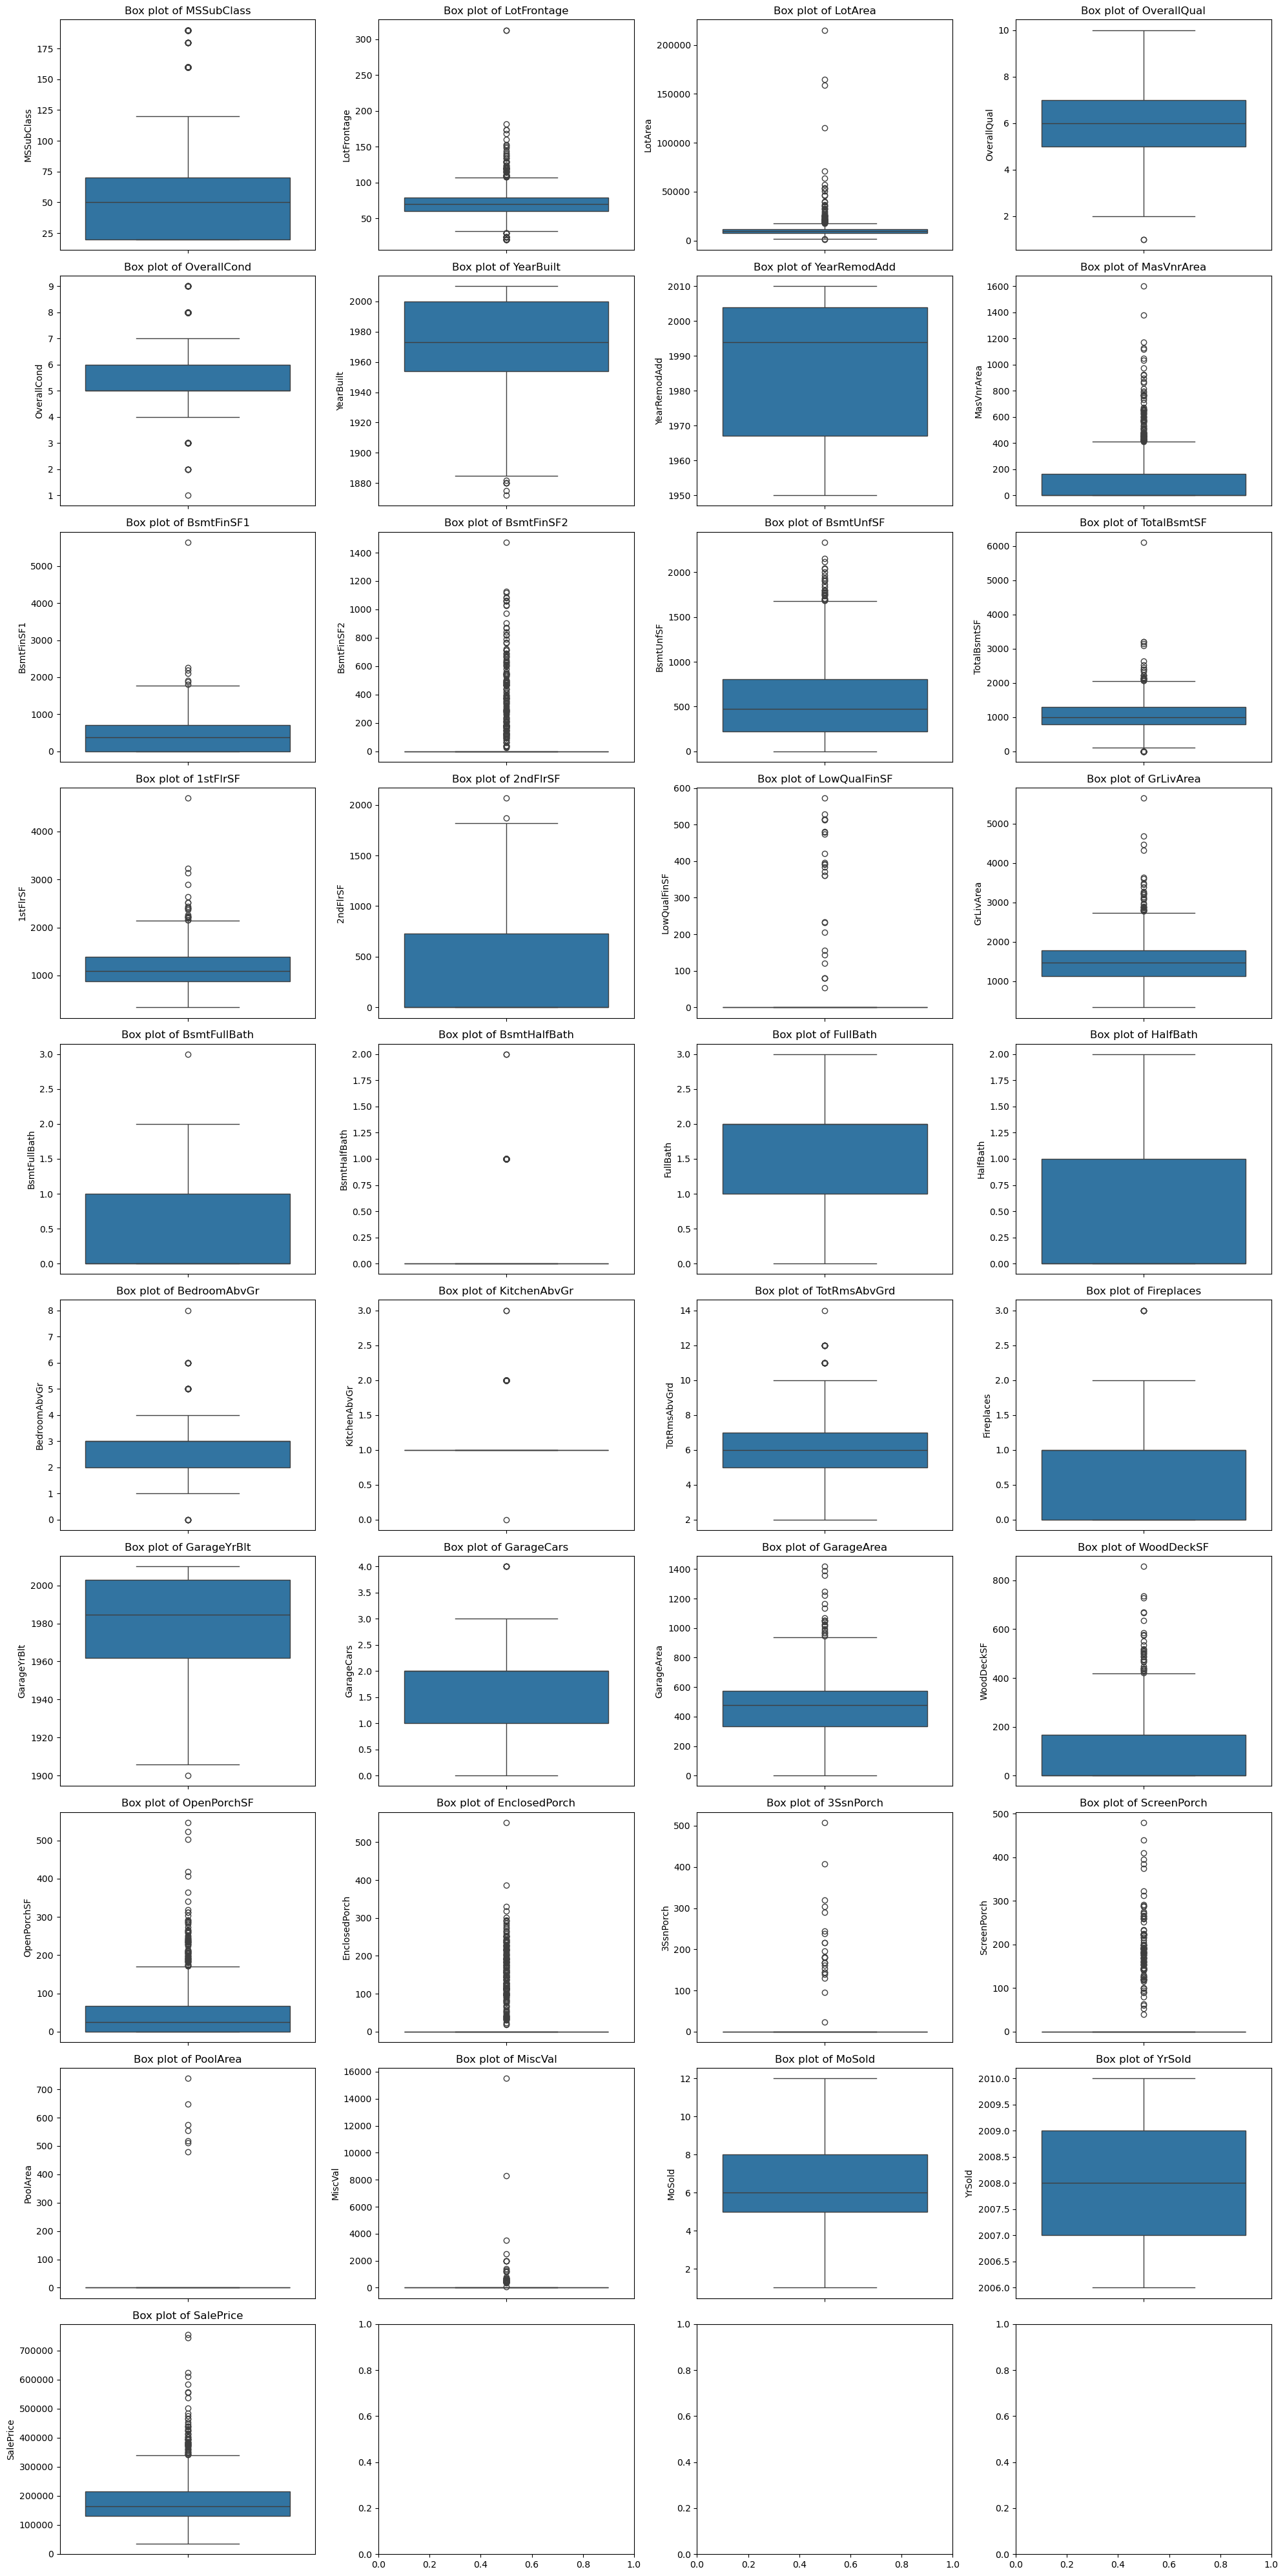

In [8]:
# Generate box plots subplots for numerical columns, to check for outliers
num_cols = len(numerical_cols)
cols = 4
rows = num_cols // cols + (num_cols % cols > 0)
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Box plot of {col}')
plt.tight_layout()
plt.show()


#### For some box plots median seems to be colling with 2nd / 3r quartile, which means there is some skew

In [9]:

# identify columns with skewness greater than 1 or less than -1
skewed_cols = df[numerical_cols].skew().sort_values(ascending=False)
high_skew = skewed_cols[abs(skewed_cols) > 1]
print('\nColumns with high skewness (>|1|):')
print(high_skew)


Columns with high skewness (>|1|):
MiscVal          24.476794
PoolArea         14.828374
LotArea          12.207688
3SsnPorch        10.304342
LowQualFinSF      9.011341
KitchenAbvGr      4.488397
BsmtFinSF2        4.255261
ScreenPorch       4.122214
BsmtHalfBath      4.103403
EnclosedPorch     3.089872
MasVnrArea        2.676412
LotFrontage       2.384950
OpenPorchSF       2.364342
SalePrice         1.882876
BsmtFinSF1        1.685503
WoodDeckSF        1.541376
TotalBsmtSF       1.524255
MSSubClass        1.407657
1stFlrSF          1.376757
GrLivArea         1.366560
dtype: float64



Columns with high skewness after log transformation (>|1|):
PoolArea         14.363102
3SsnPorch         7.734975
LowQualFinSF      7.460317
MiscVal           5.170704
BsmtHalfBath      3.933064
KitchenAbvGr      3.869414
ScreenPorch       3.150409
BsmtFinSF2        2.523694
EnclosedPorch     2.112275
SalePrice         1.882876
TotalBsmtSF      -5.154670
dtype: float64

Columns where skewness was fixed with log transformation:
{'OpenPorchSF', 'WoodDeckSF', 'GrLivArea', 'MSSubClass', '1stFlrSF', 'BsmtFinSF1', 'MasVnrArea', 'LotFrontage', 'LotArea'}

Columns still skewed after log transformation (to be treated later):
['PoolArea', '3SsnPorch', 'LowQualFinSF', 'MiscVal', 'BsmtHalfBath', 'KitchenAbvGr', 'ScreenPorch', 'BsmtFinSF2', 'EnclosedPorch', 'SalePrice', 'TotalBsmtSF']

Numerical Columns after removing still skewed columns,( 26 ):
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtUnfSF', '1stFlrSF', 

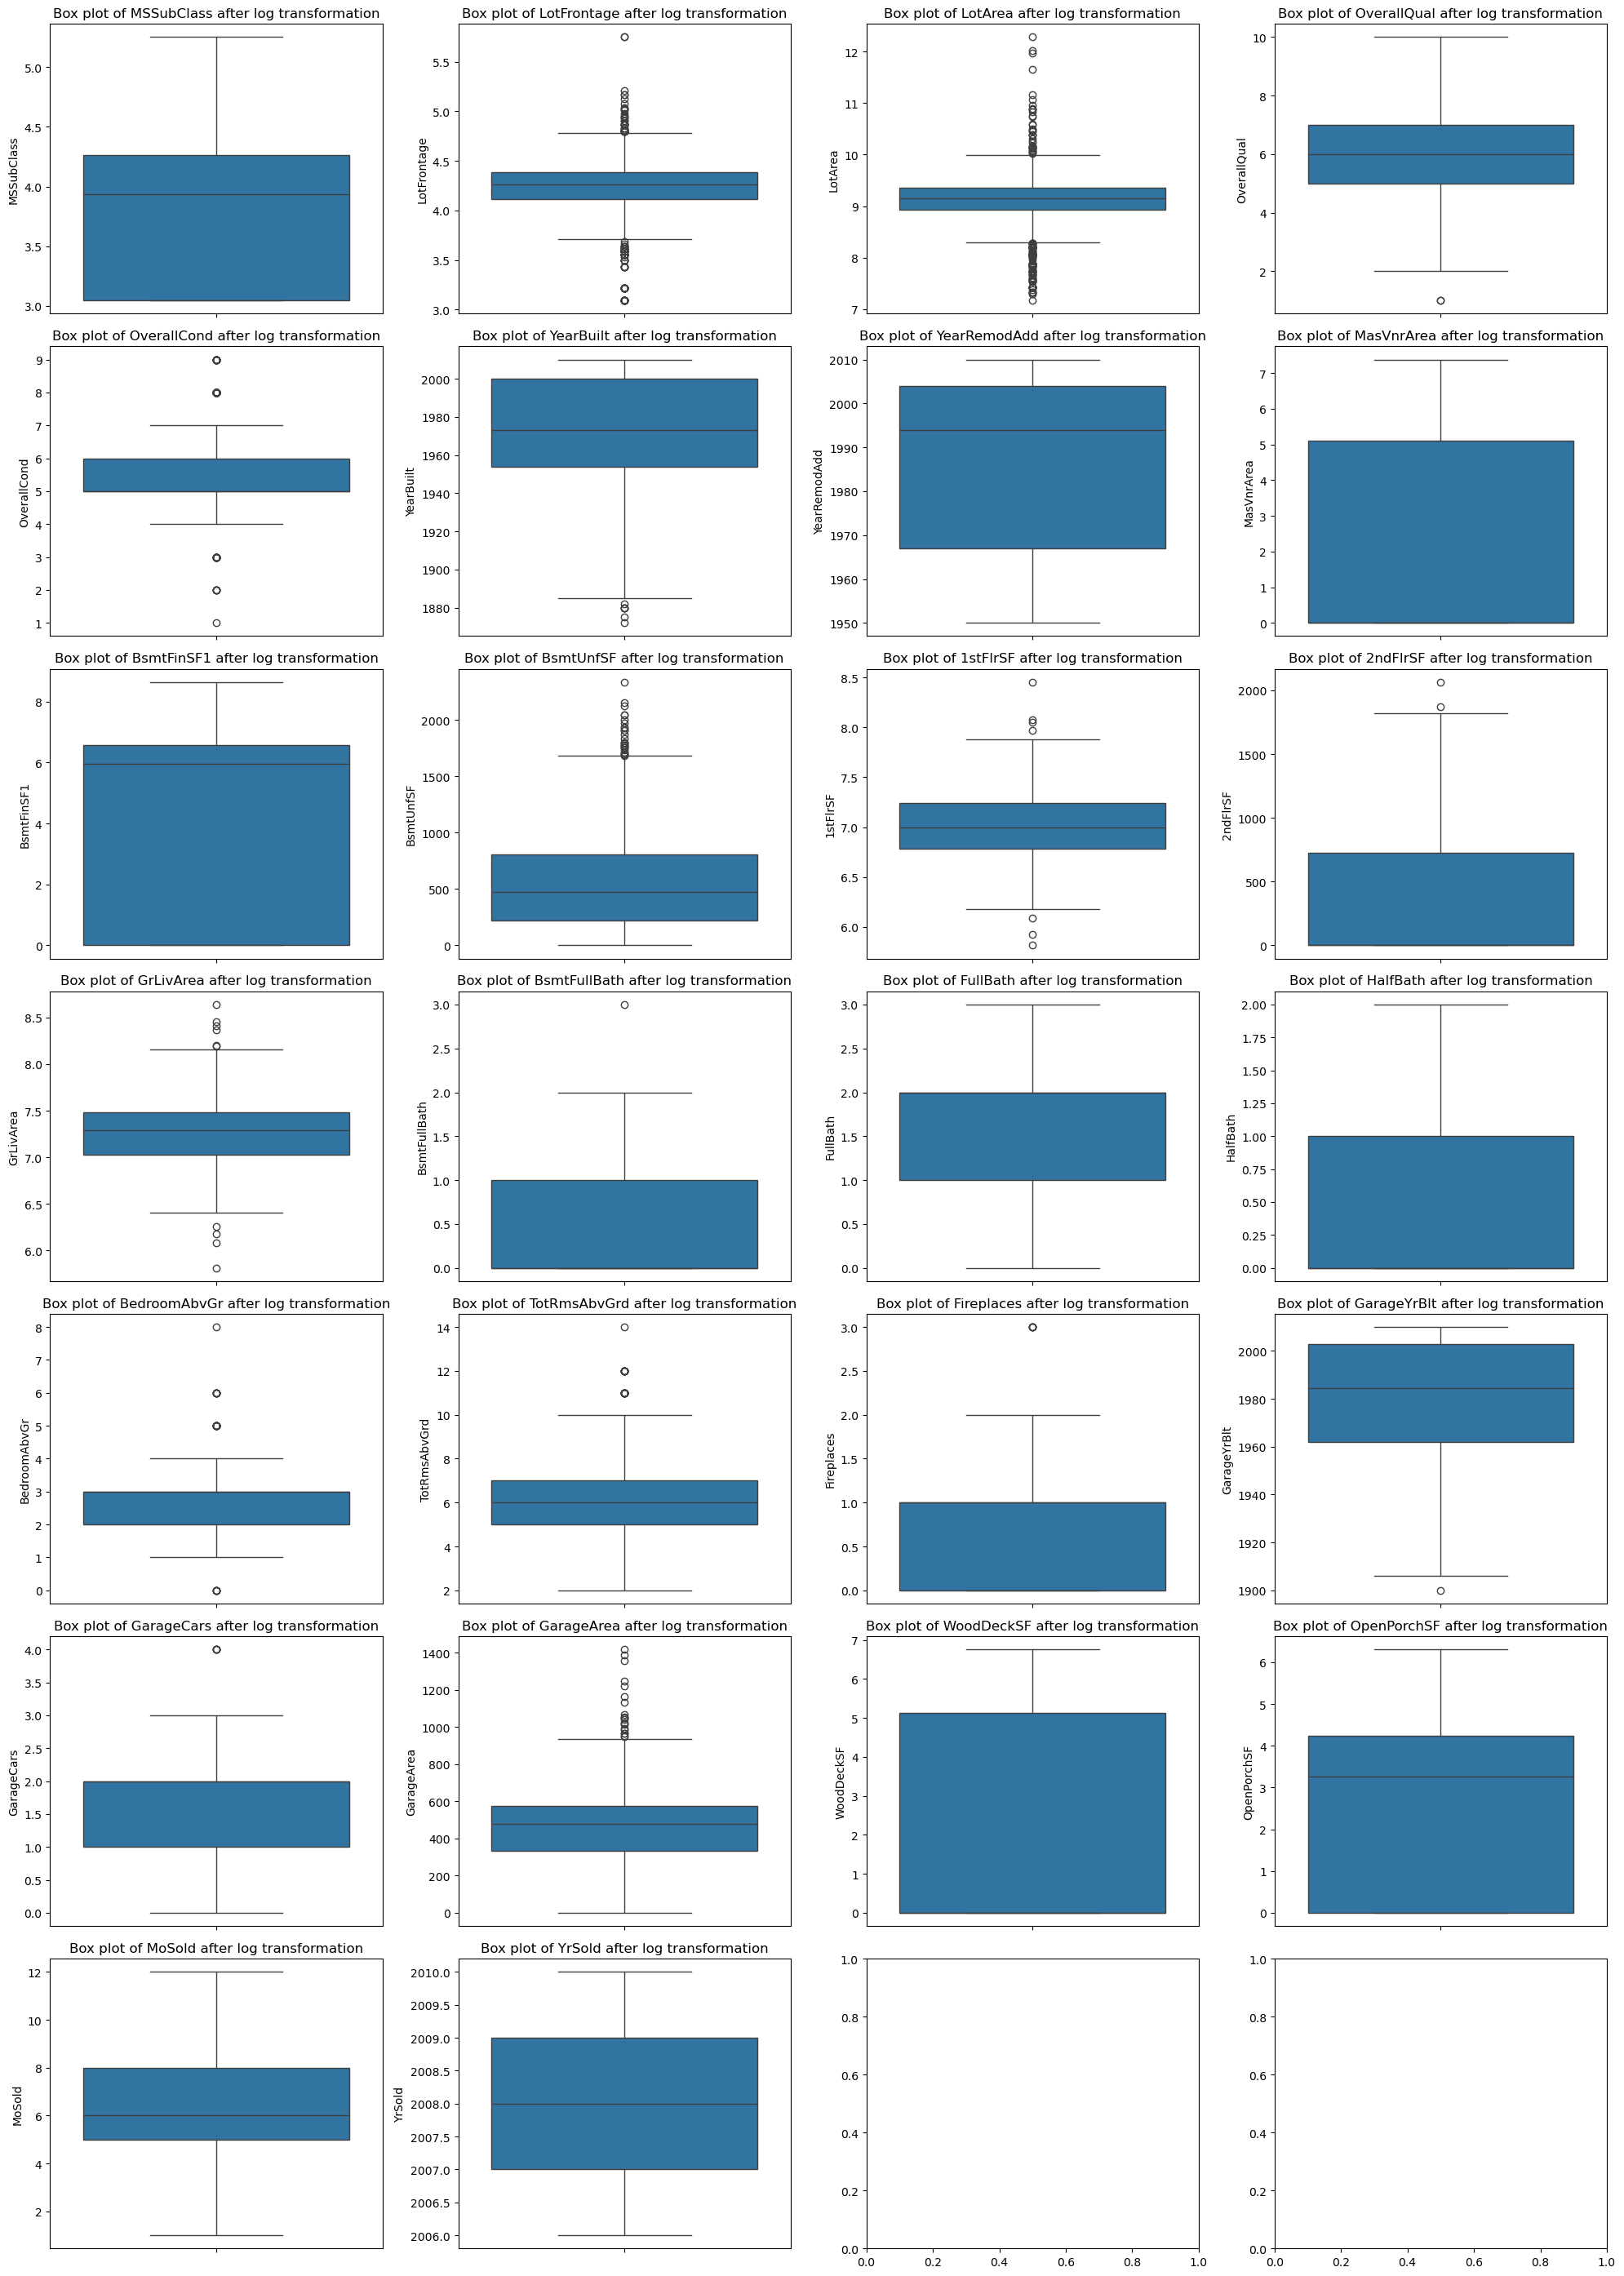

In [10]:
#apply log transformation to skewed columns, excluding the target variable 'SalePrice', and regenerate skewness values as well as box plots subplots
for col in high_skew.index:
    if col != 'SalePrice':
        df[col] = np.log1p(df[col])

# Regenerate skewness values
skewed_cols_after = df[numerical_cols].skew().sort_values(ascending=False)
high_skew_after = skewed_cols_after[abs(skewed_cols_after) > 1]
print('\nColumns with high skewness after log transformation (>|1|):')
print(high_skew_after)

#revert log transformation for columns that are still skewed, excluding the target variable 'SalePrice'
for col in high_skew_after.index:
    if col != 'SalePrice':
        df[col] = np.expm1(df[col])

#print columns where skewness was fix with log transformation
fixed_skew_byLog_cols = set(high_skew.index) - set(high_skew_after.index)
print('\nColumns where skewness was fixed with log transformation:')
print(fixed_skew_byLog_cols)

#create list of columns which are still skewed after log transformation
still_skewed_cols = list(high_skew_after.index)
print('\nColumns still skewed after log transformation (to be treated later):')
print(still_skewed_cols)

# remove still skewed columns from numerical_cols list for box plot generation
numerical_cols = [col for col in numerical_cols if col not in still_skewed_cols]
print('\nNumerical Columns after removing still skewed columns,(', len(numerical_cols), '):')
print(numerical_cols)


# Generate box plots subplots for numerical columns after log transformation, to check for outliers
num_cols = len(numerical_cols)
cols = 4
rows = num_cols // cols + (num_cols % cols > 0)
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Box plot of {col} after log transformation')
plt.tight_layout()
plt.show()

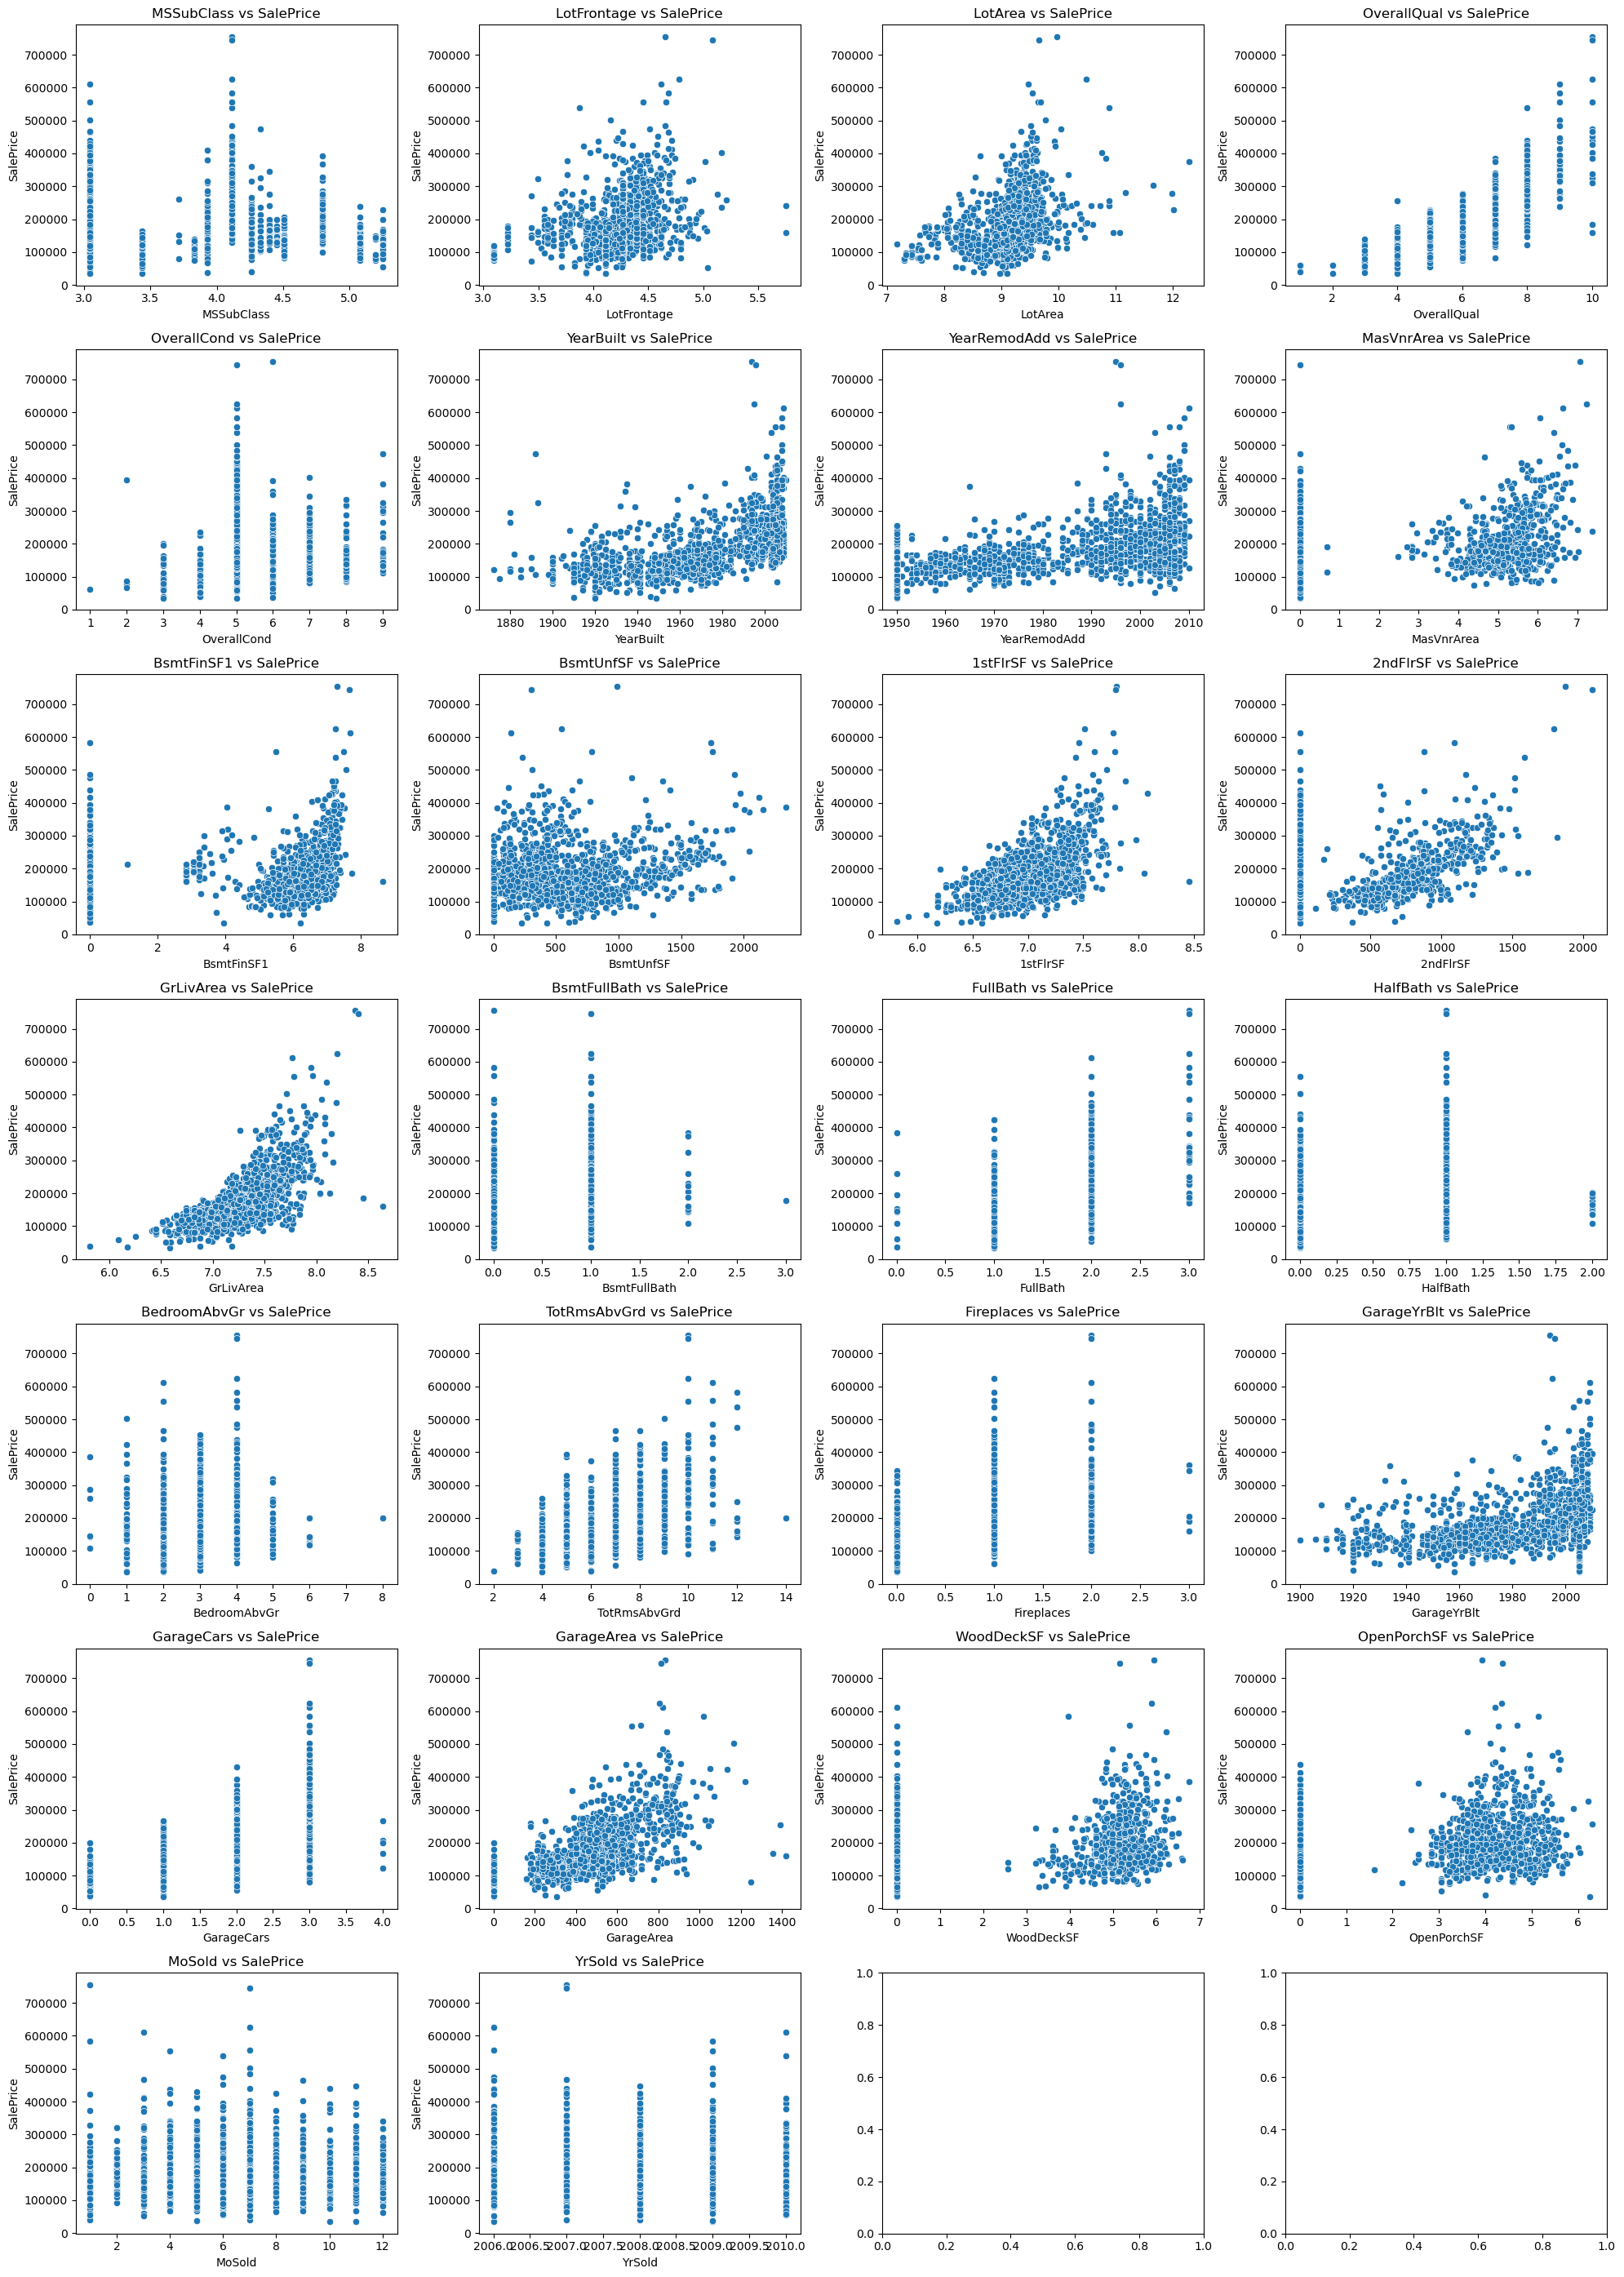

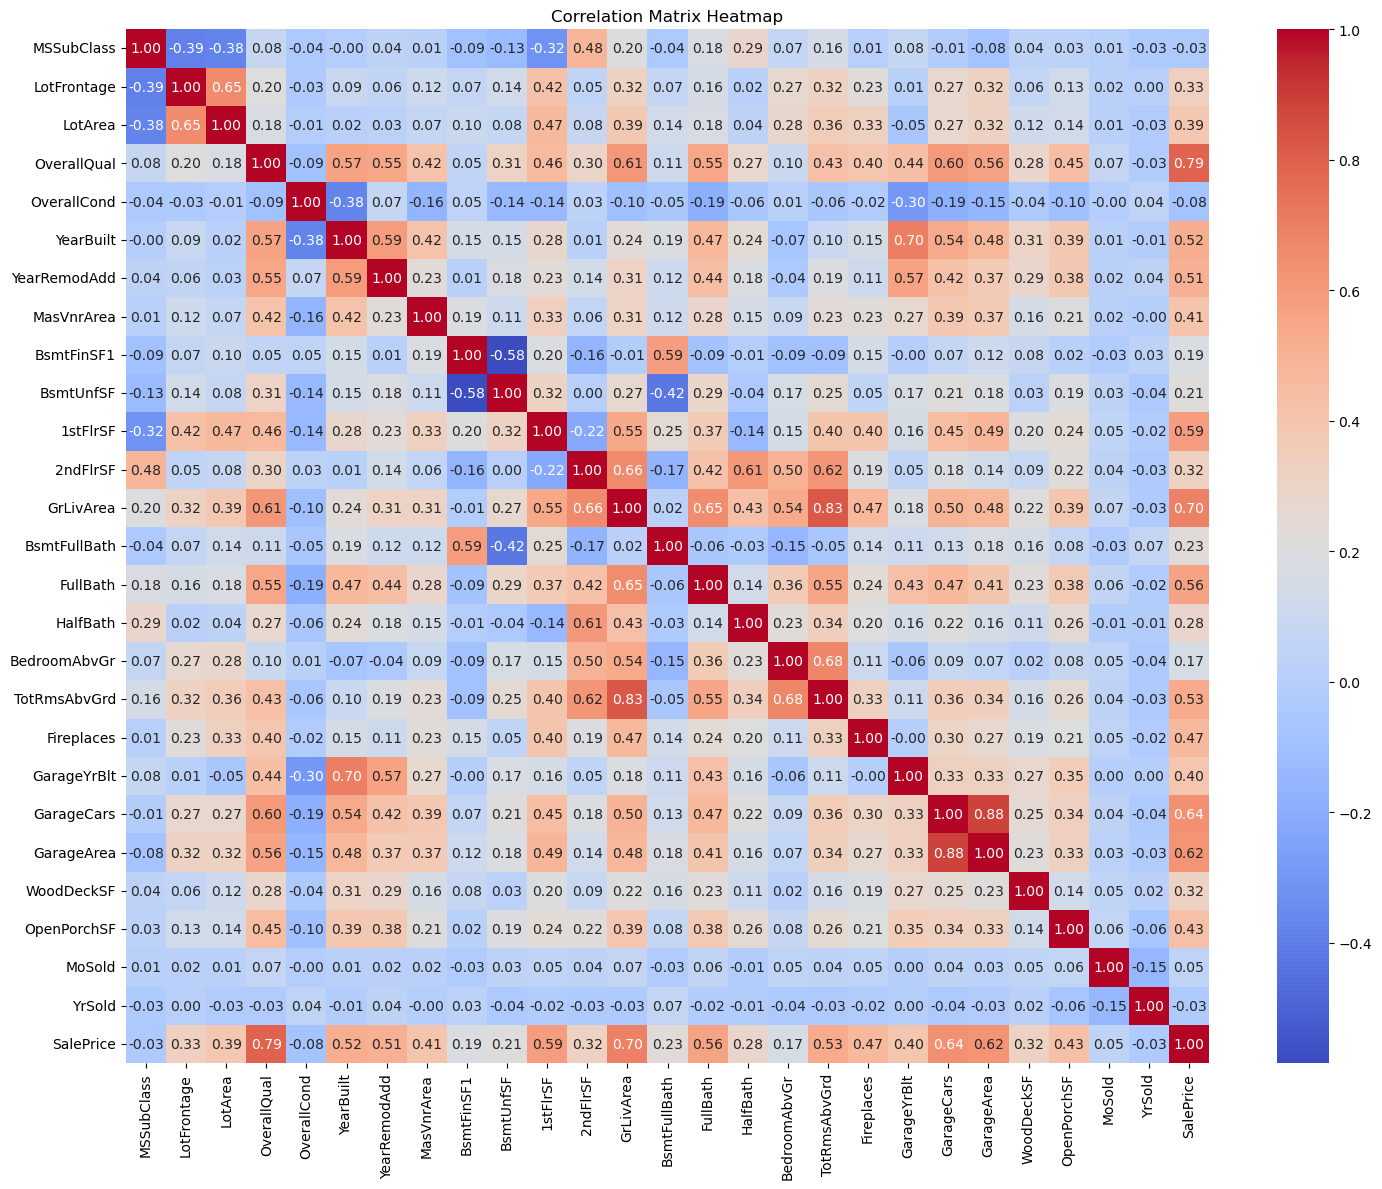

In [11]:
# Generate subplot for relation of numerical columns with Target variable 'SalePrice'
num_cols = len(numerical_cols)
cols = 4
rows = num_cols // cols + (num_cols % cols > 0)
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.scatterplot(x=df[col], y=df['SalePrice'], ax=axes[i])
    axes[i].set_title(f'{col} vs SalePrice')
plt.tight_layout()
plt.show()

#generate correlation matrix heatmap for numerical columns including SalePrice
correlation_df = df[numerical_cols]
correlation_df['SalePrice'] = df['SalePrice']
corr_matrix = correlation_df.corr()
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()



In [12]:

## HANDLING SKEWED NUMERICAL COLUMNS TO BE TREATED AS CATEGORICAL

"""
PoolArea         14.353321
3SsnPorch         7.623787
LowQualFinSF      7.311580
MiscVal           5.025194
BsmtHalfBath      3.862022
ScreenPorch       3.115763
BsmtFinSF2        2.432934
EnclosedPorch     2.052809
SalePrice         1.882876
LotFrontage      -1.287863
TotalBsmtSF      -5.982213
KitchenAbvGr    -12.125198

MSSubClass
"""

# #numerical to be treated as categorical
# KitchenAbvGr(only 4 distinct values [0.69 - 1392 rows, 1.09 -65 rows, 1.38 - 2 rows, 0 - i row])
# convert all values of KitchenAbvGr < 1 to 0.5, and all values from 1 - 1.5 to 1, then treat as categorical variable
df['KitchenAbvGr'] = df['KitchenAbvGr'].apply(lambda x: 0.5 if x < 1 else (1 if x > 1 else x))
categorial_cols.append('KitchenAbvGr')


# # BsmtHalfBath(only 3 distinct values: 0 in 1378 rows, 0.69, 1.099)
# # convert all values of BsmtHalfBath < 1 to 0.5, and all values from 1 - 1.5 to 1, then treat as categorical variable
# df['BsmtHalfBath'] = df['BsmtHalfBath'].apply(lambda x: 0.5 if x < 1 else (1 if x > 1 else x))
# categorial_cols.append('BsmtHalfBath')

#PoolArea (0 -1453 rows, rest values [512, 648, 576, 555, 480, 519, 738])
# convert all values of PoolArea = 0 to No: for 'No Pool', and rest values to Yes: for 'Has Pool'
df['PoolArea'] = df['PoolArea'].apply(lambda x: 'No' if x == 0 else 'Yes')
categorial_cols.append('PoolArea')

#3SsnPorch (0 - 1436 rows, 19 rows has values ranging between 90 - 500)
# convert all values of 3SsnPorch = 0 to No: for 'No Porch', and rest values to Yes: for 'Has Porch'
df['3SsnPorch'] = df['3SsnPorch'].apply(lambda x: 'No' if x == 0 else 'Yes')
categorial_cols.append('3SsnPorch')

# #BsmtHalfBath [0.5 - 1378 rows, 1.0 - 82 rows]
# categorial_cols.append('BsmtHalfBath')

# # LotFrontage (use floor/cieling function to reduce skewness) and then treat as categorical variable
# # Before floor function [111 unique values rangin from 4.xx - 5.xx]
# df['LotFrontage'] = df['LotFrontage'].apply(np.floor)
# #After floor function [4.0 - 1205 rows, 3.0 - 244 rows, 5.0 11 rows]
# categorial_cols.append('LotFrontage')
# numerical_cols.remove('LotFrontage')

# # MSSubClass (only 15 distinct values), (use floor/cieling function to reduce skewness) and then treat as categorical variable
# df['MSSubClass'] = df['MSSubClass'].apply(np.floor)
# categorial_cols.append('MSSubClass')
# numerical_cols.remove('MSSubClass')
#After floor function [3.0 - 765 rows, 4.0 - 592 rows, 5.0 - 103 rows]

# Looking at semantic meaning as per data dictionary adding below numerical columns back to numerical_cols list despite having skewed distribution
numerical_cols.append('LowQualFinSF')
numerical_cols.append('MiscVal')
numerical_cols.append('ScreenPorch')
numerical_cols.append('BsmtFinSF2')
numerical_cols.append('EnclosedPorch')
numerical_cols.append('TotalBsmtSF')

# Commented out this: 
#   - This logic had very bad impact on model performance during experimentation
# Columns with numerical value but categorical in nature,remove from numerical_cols and add to categorial_cols
# numerical_cols.remove('OverallCond')
# categorial_cols.append('OverallCond')

# numerical_cols.remove('BsmtFullBath')
# categorial_cols.append('BsmtFullBath')

# numerical_cols.remove('OverallQual')
# categorial_cols.append('OverallQual')

# numerical_cols.remove('TotRmsAbvGrd')
# categorial_cols.append('TotRmsAbvGrd')

# numerical_cols.remove('BedroomAbvGr')
# categorial_cols.append('BedroomAbvGr')

# numerical_cols.remove('Fireplaces')
# categorial_cols.append('Fireplaces')

# numerical_cols.remove('GarageCars')
# categorial_cols.append('GarageCars')

# numerical_cols.remove('MoSold')
# categorial_cols.append('MoSold')

# numerical_cols.remove('YrSold')
# categorial_cols.append('YrSold')


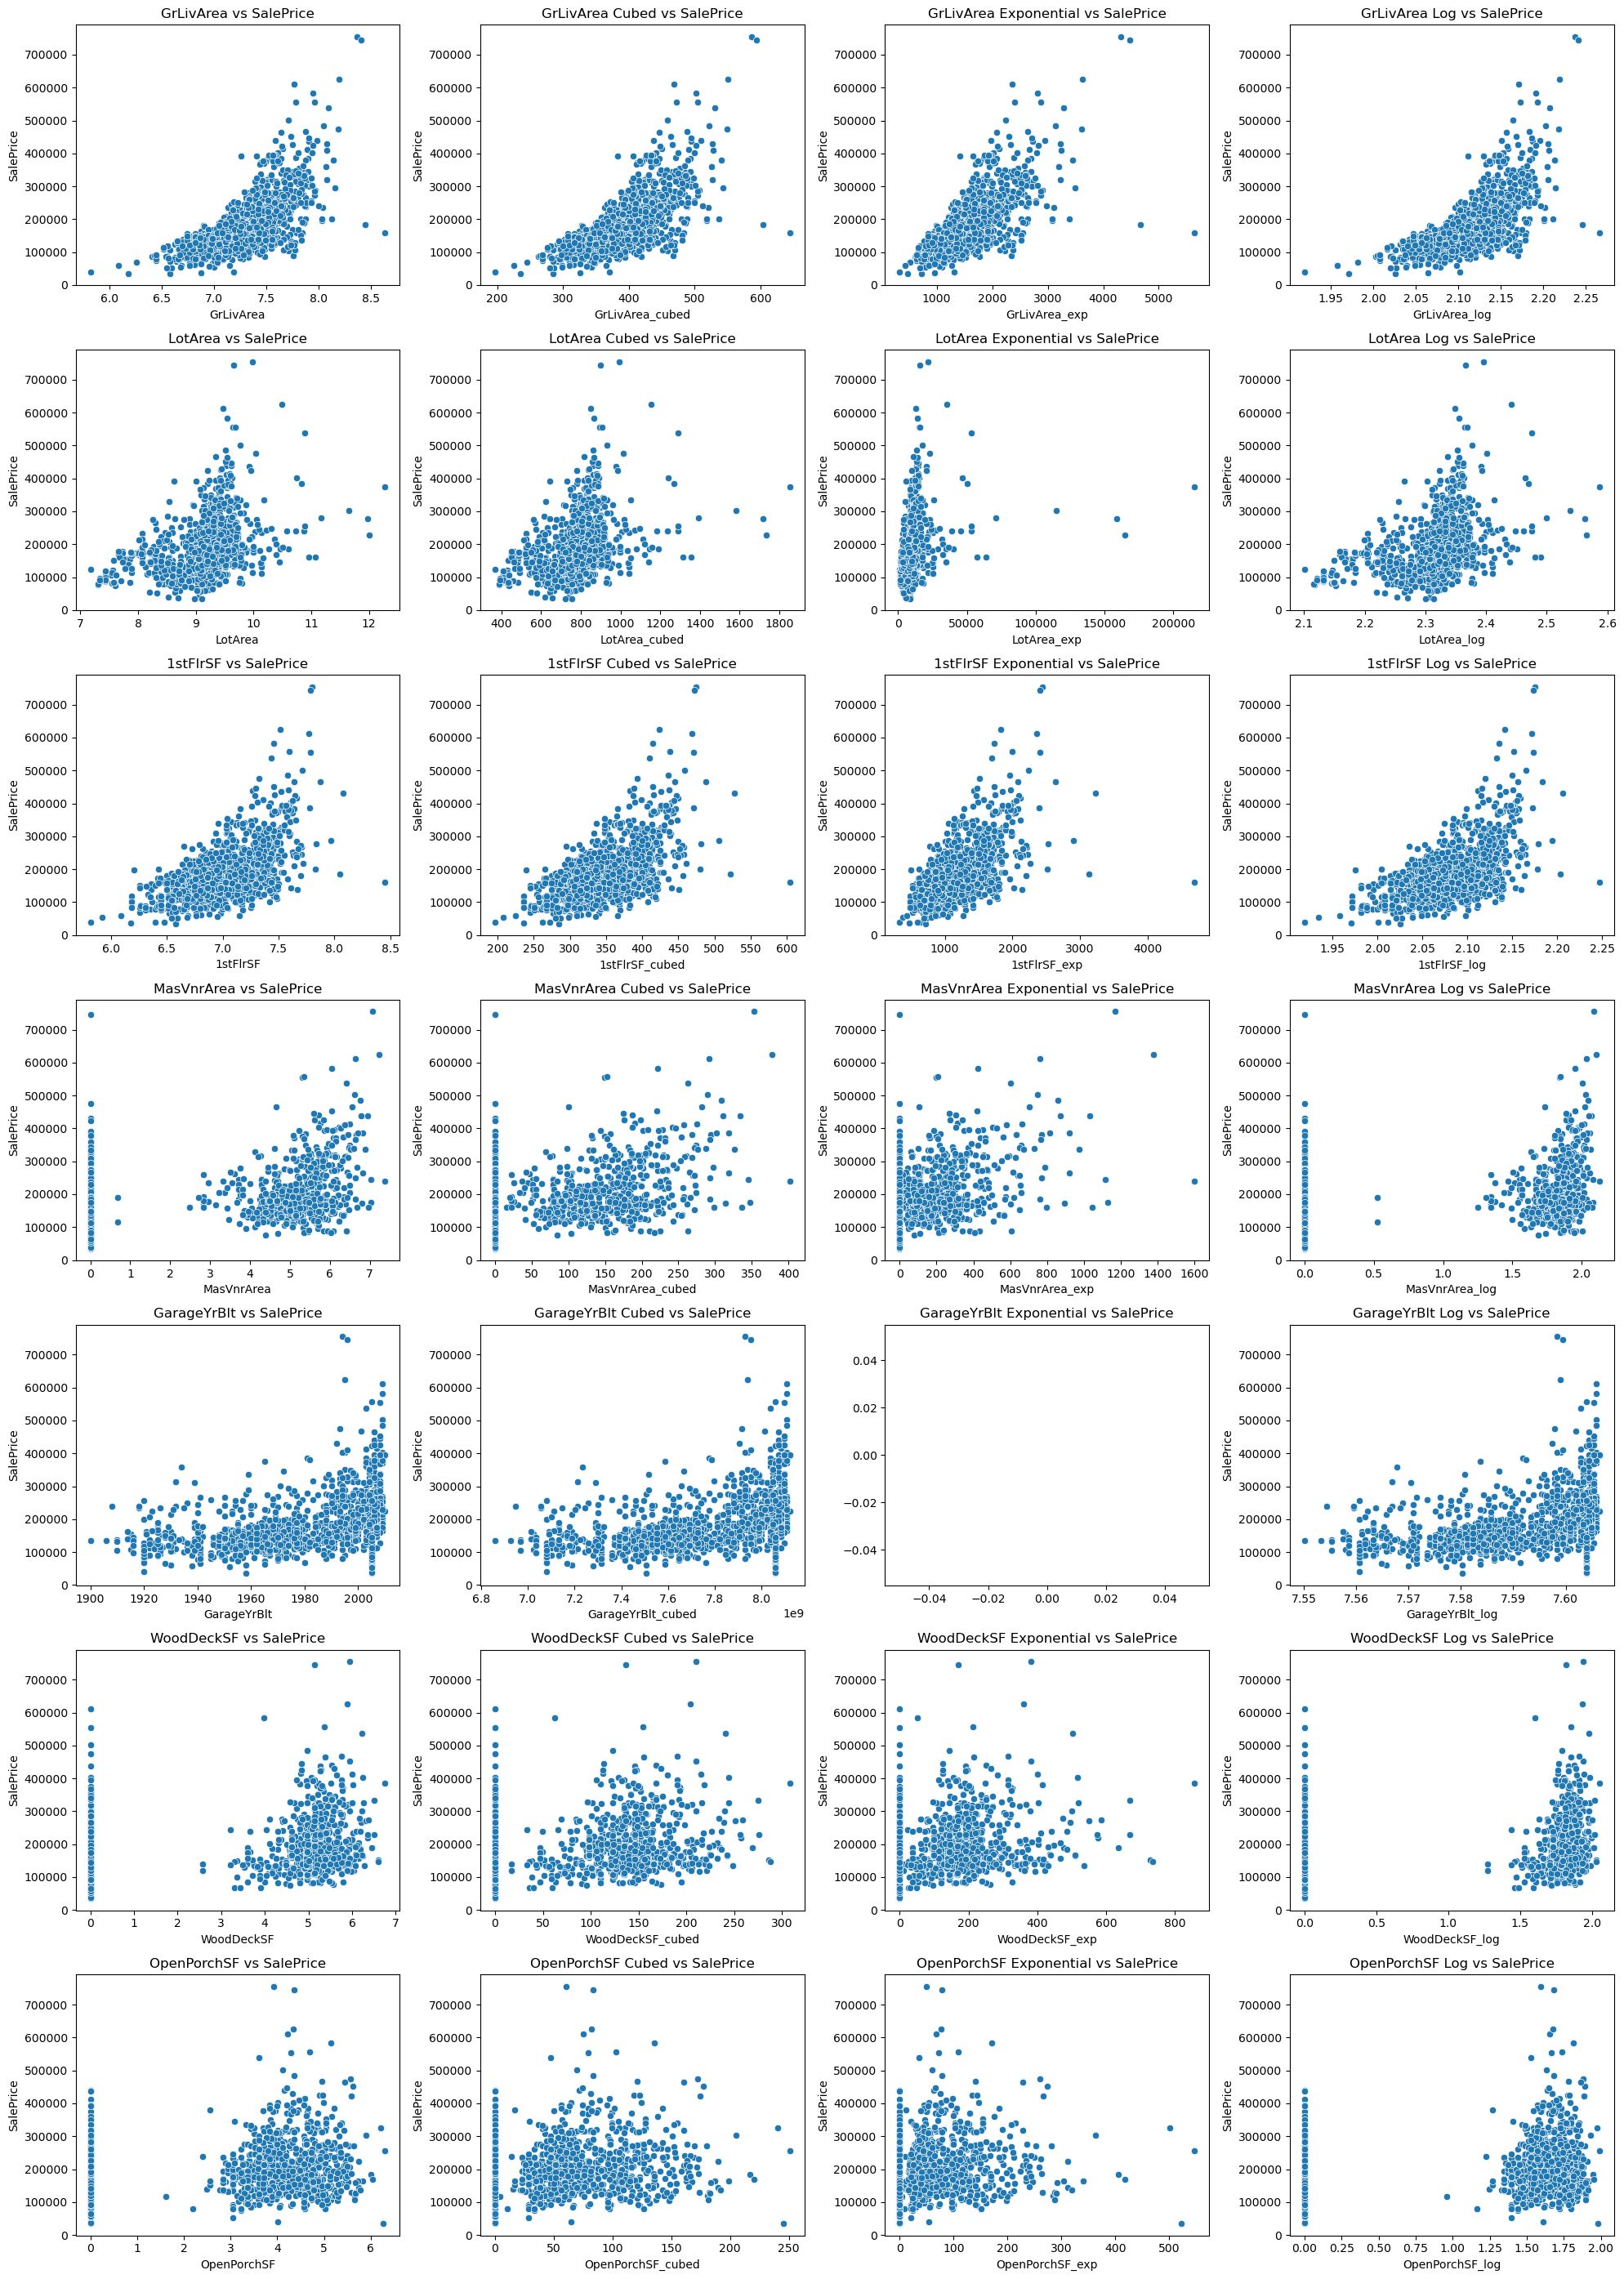

In [13]:
# From the scatter plots generated earlier, following columns show non-linear relationship with target variable SalePrice
non_linear_cols = ['GrLivArea', 'LotArea', '1stFlrSF', 'MasVnrArea', 'GarageYrBlt', 'WoodDeckSF', 'OpenPorchSF']

temp_df = df[non_linear_cols + ['SalePrice']]

# check with x3, exponential and log transofrmations
for col in non_linear_cols:
    temp_df[f'{col}_cubed'] = temp_df[col] ** 3
    temp_df[f'{col}_exp'] = np.expm1(temp_df[col])
    temp_df[f'{col}_log'] = np.log1p(temp_df[col])

# Generate subplot for relation of transformed numerical columns with Target variable 'SalePrice'
# Also include original columns for comparison
num_cols = len(non_linear_cols) * 4  # original + 3 transformations
cols = 4
rows = num_cols // cols + (num_cols % cols > 0)
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()
i = 0
for col in non_linear_cols:
    sns.scatterplot(x=temp_df[col], y=temp_df['SalePrice'], ax=axes[i])
    axes[i].set_title(f'{col} vs SalePrice')
    i += 1
    sns.scatterplot(x=temp_df[f'{col}_cubed'], y=temp_df['SalePrice'], ax=axes[i])
    axes[i].set_title(f'{col} Cubed vs SalePrice')
    i += 1
    sns.scatterplot(x=temp_df[f'{col}_exp'], y=temp_df['SalePrice'], ax=axes[i])
    axes[i].set_title(f'{col} Exponential vs SalePrice')
    i += 1
    sns.scatterplot(x=temp_df[f'{col}_log'], y=temp_df['SalePrice'], ax=axes[i])
    axes[i].set_title(f'{col} Log vs SalePrice')
    i += 1
plt.tight_layout()
plt.show()



['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtUnfSF', '1stFlrSF', '2ndFlrSF', 'GrLivArea', 'BsmtFullBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'MoSold', 'YrSold', 'LowQualFinSF', 'MiscVal', 'ScreenPorch', 'BsmtFinSF2', 'EnclosedPorch', 'TotalBsmtSF']


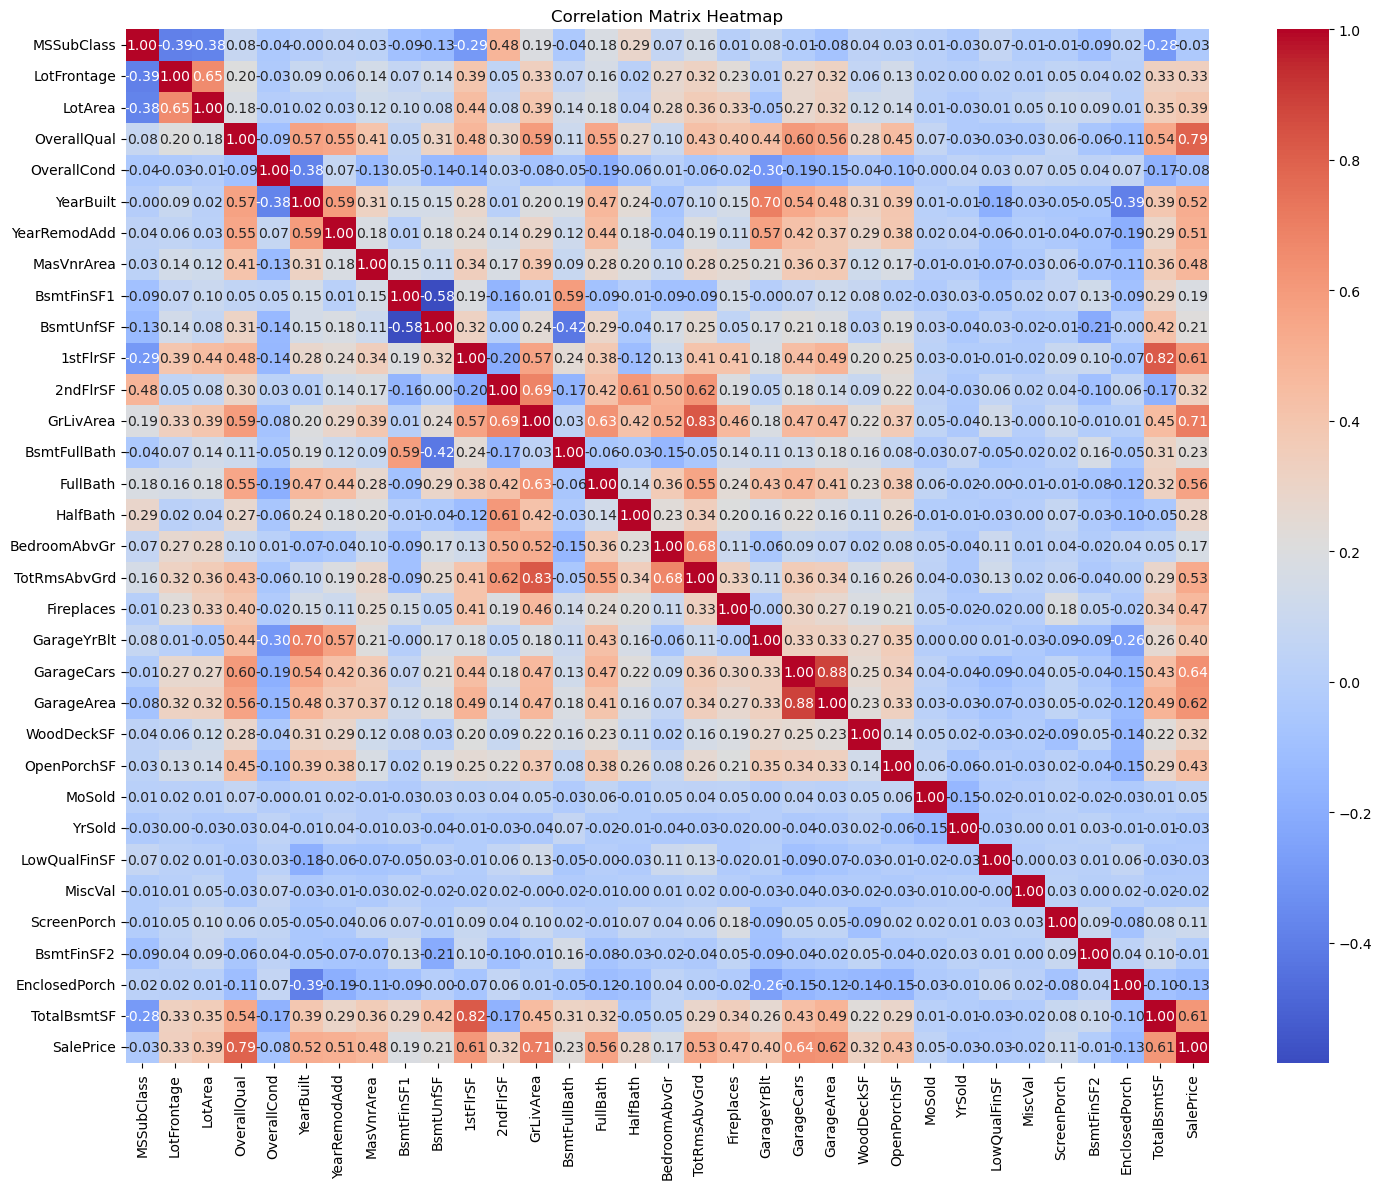

In [14]:
# From the transformation plots, we can see that: exponential transformation works best for GrLivArea, 1stFlrSF, MasVnrArea, BsmtFinSF1
for col in ['GrLivArea', '1stFlrSF', 'MasVnrArea']:
    df[col] = np.expm1(df[col])

# Create correlation matrix heatmap for numerical columns including SalePrice after handling non-linear relationships
print(numerical_cols)
correlation_df = df[numerical_cols]
correlation_df['SalePrice'] = df['SalePrice']
corr_matrix = correlation_df.corr()
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

# Correlation matrix shows improved correlation of these columns with SalePrice after exponential transformation

In [15]:
# Based on correlation matrix, removing some columns [2ndFlrSF, HalfBath, BedroomAbvGr, GarageYrBlt, BsmtUnfSF]
df = df.drop(columns=['2ndFlrSF', 'HalfBath', 'BedroomAbvGr', 'GarageYrBlt', 'BsmtUnfSF', 'BsmtFinSF1'])
numerical_cols.remove('2ndFlrSF')
numerical_cols.remove('HalfBath')
numerical_cols.remove('BedroomAbvGr')
numerical_cols.remove('GarageYrBlt')
numerical_cols.remove('BsmtUnfSF')
numerical_cols.remove('BsmtFinSF1')

### 3.b Analysing Categorical Variables


Categorical Columns,( 42 ):
['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition', 'KitchenAbvGr', 'PoolArea', '3SsnPorch']


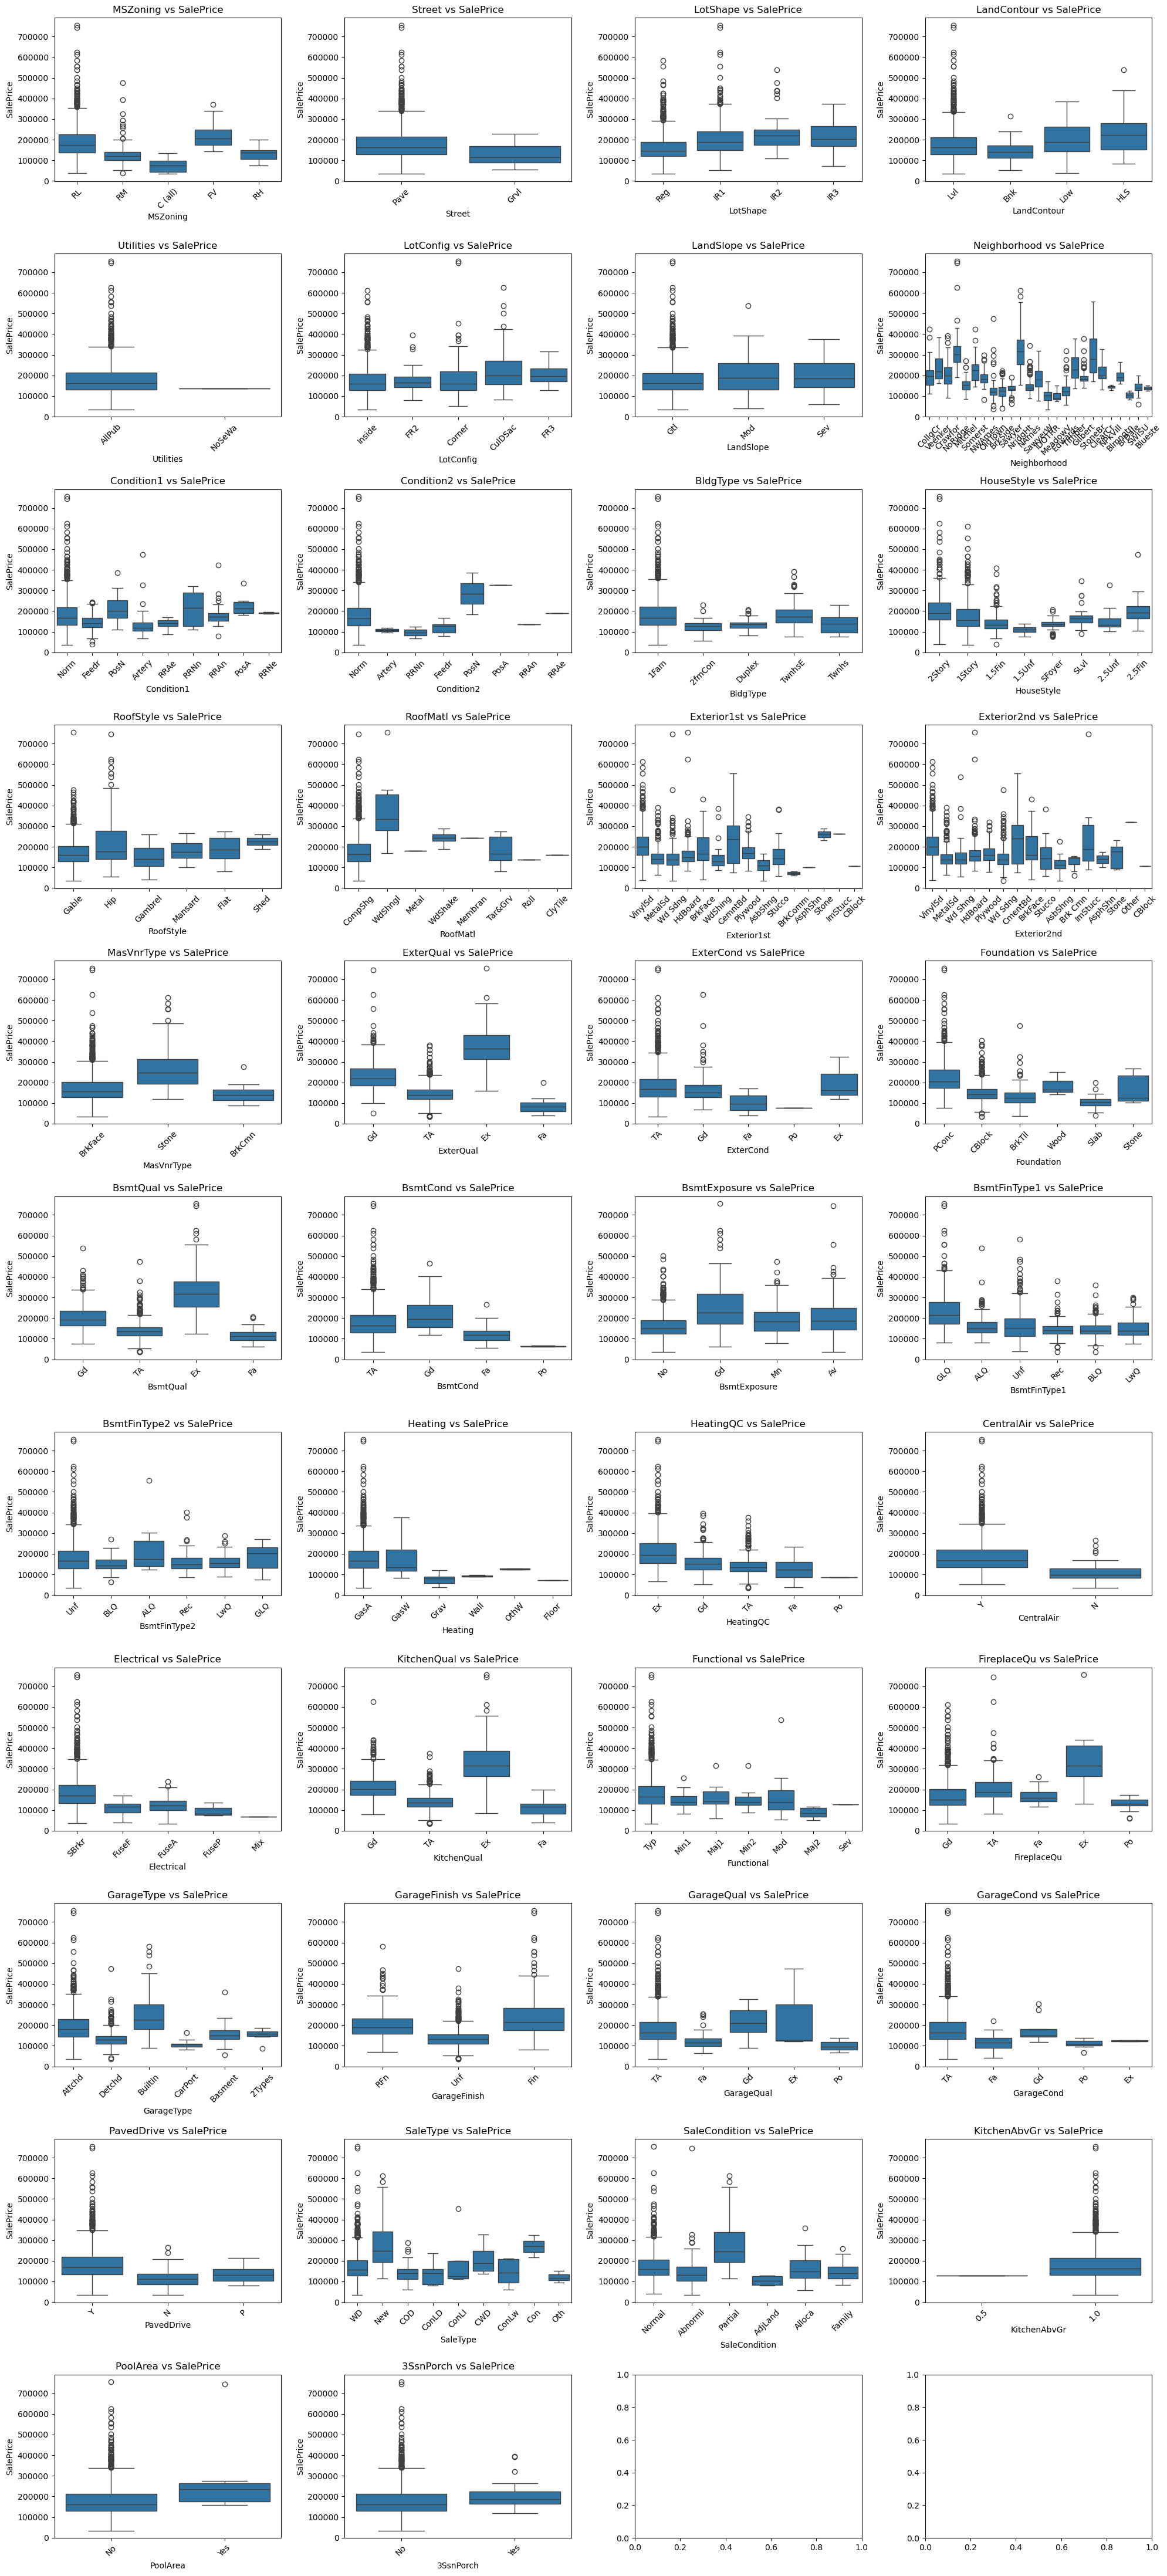

In [16]:
print('\nCategorical Columns,(', len(categorial_cols), '):')
print(categorial_cols)

#Categorical variables visualization, against target variable SalePrice using box plot subplots
num_cols = len(categorial_cols)
cols = 4
rows = num_cols // cols + (num_cols % cols > 0)
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()
for i, col in enumerate(categorial_cols):
    sns.boxplot(x=df[col], y=df['SalePrice'], ax=axes[i])
    axes[i].set_title(f'{col} vs SalePrice')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()  




### Insights gained post data cleaning

- Numerical columns like 1stFlrSF, GrLivArea, FullBath, GarageArea, TotalBasementSF are found to have high positive correlation with SalePrice
- Some Numerical variables were converted to categorical variables like OverallQual, GarageCars also have high positive correlation with SalePrice
- Some Numerical variables('GrLivArea', '1stFlrSF', 'MasVnrArea', 'BsmtFinSF1') showed better linear relation after applying exponential transformation
- Categorical variables show increasing trend with OverallQual, TotRmsAbvGrd, FirePlaces, GarageCars, PoolArea



Number of rows removed due to SalePrice outlier removal: 113


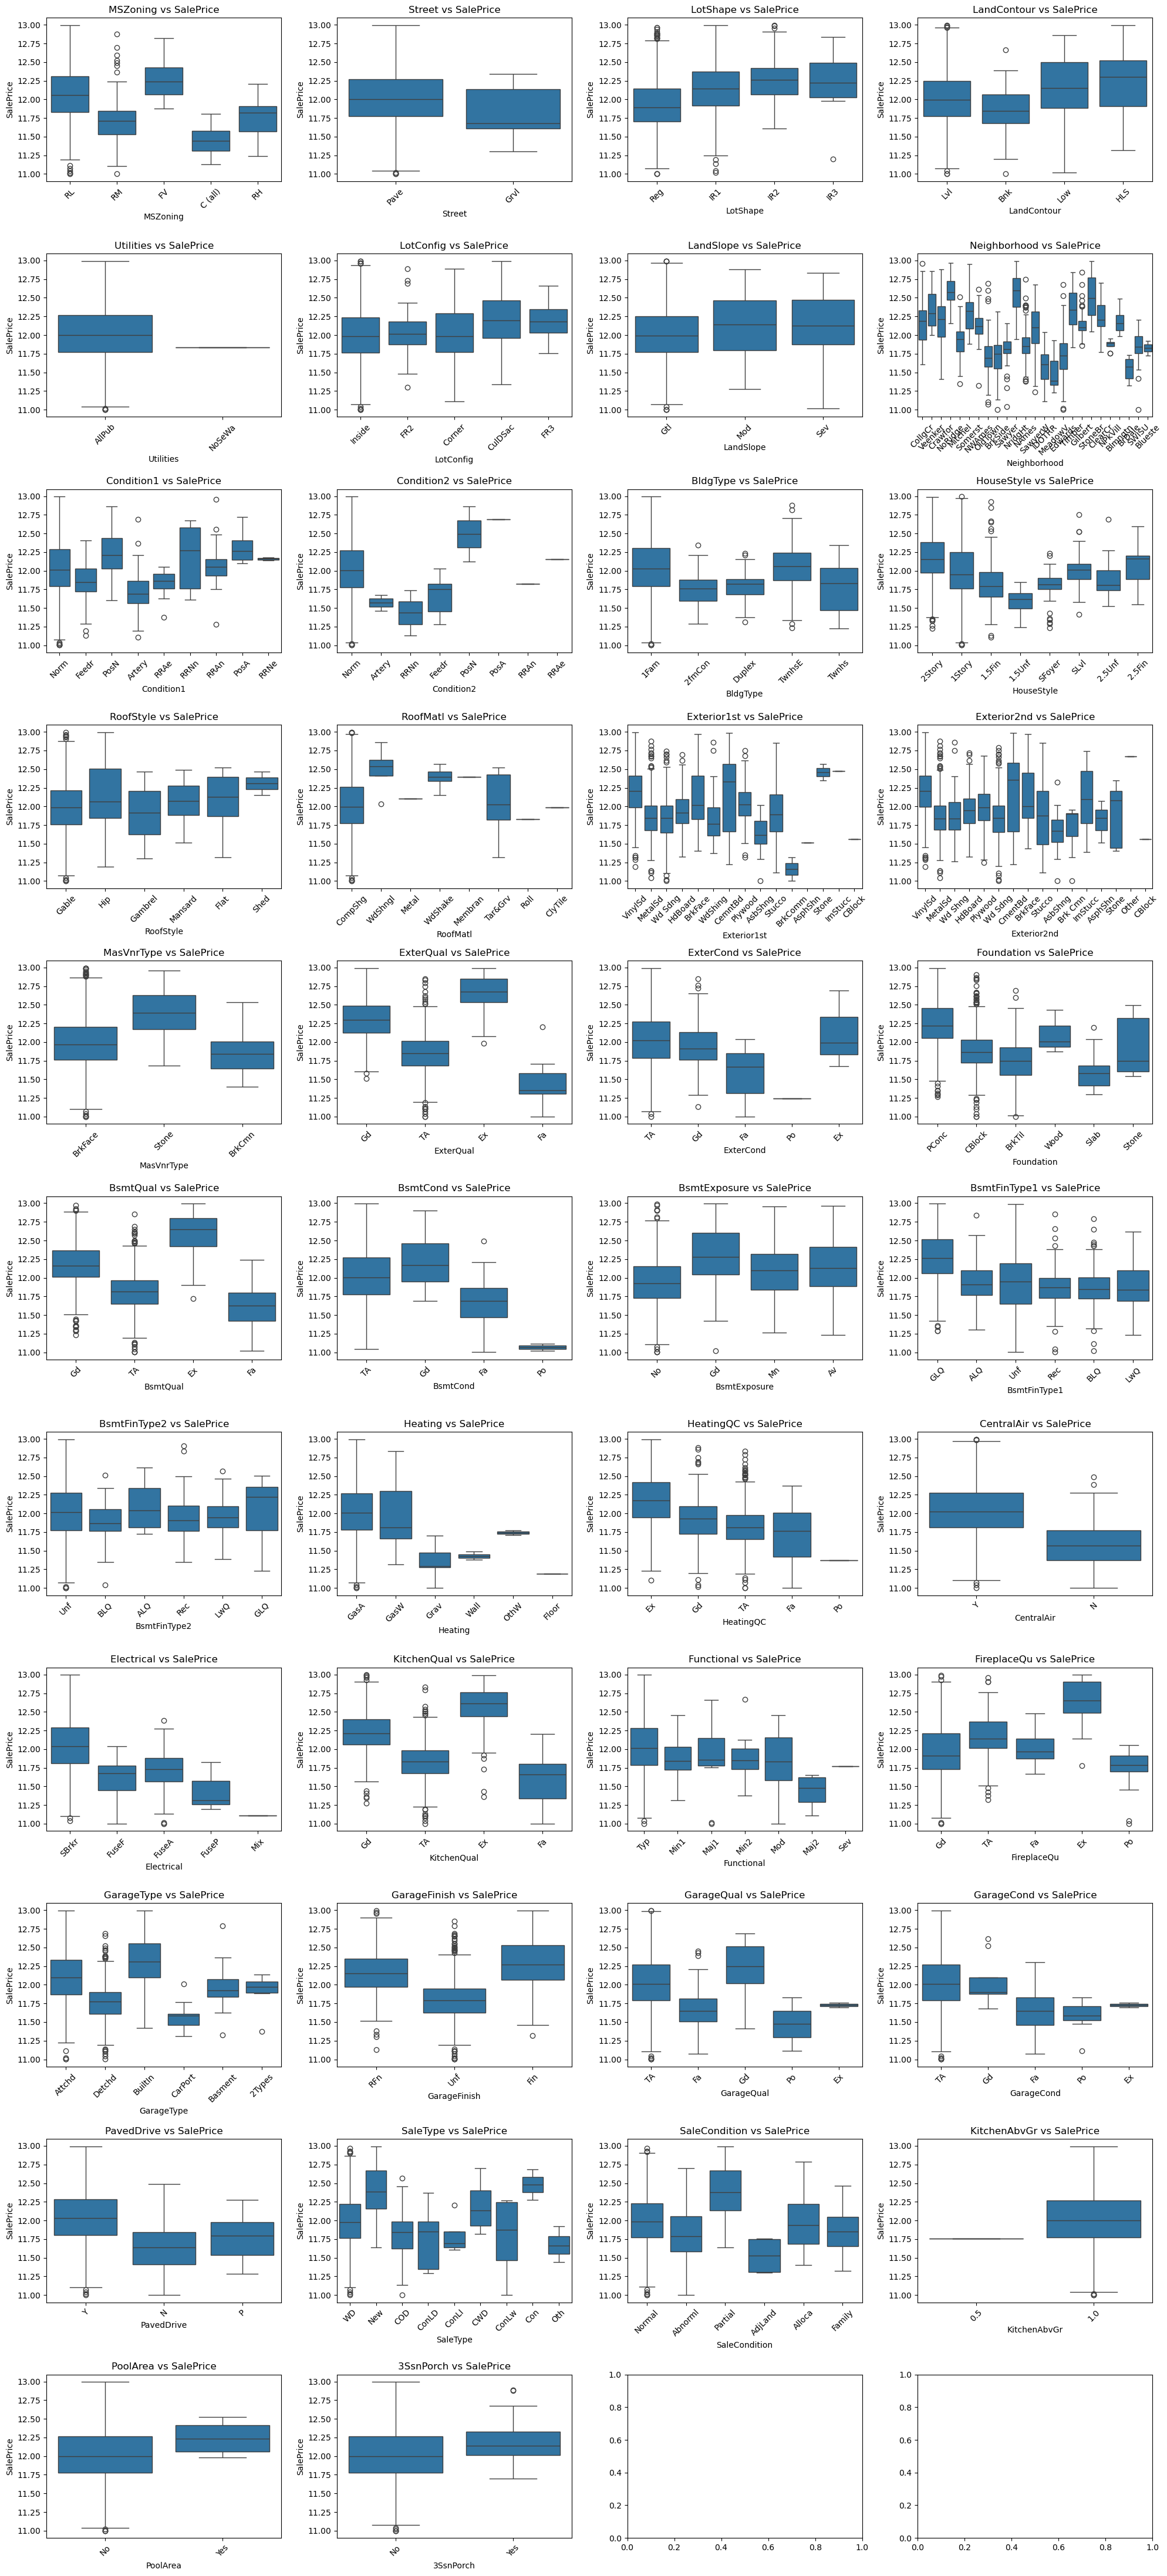

In [17]:
# apply log transformation to target variable SalePrice and re-create box plot for categorial columns against SalePrice
df['SalePrice'] = np.log1p(df['SalePrice'])

# Print number of removed rows based on SalePrice outlier removal
print('\nNumber of rows removed due to SalePrice outlier removal:', df.shape[0] - df[(df['SalePrice'] <= 12.65) & (df['SalePrice'] >= 11.0)].shape[0])

#drop rows where SalePrice > 13 (to remove extreme outliers)
df = df[(df['SalePrice'] <= 13.0) & (df['SalePrice'] >= 11.0)]

#Categorical variables visualization, against target variable SalePrice using box plot subplots
num_cols = len(categorial_cols)
cols = 4
rows = num_cols // cols + (num_cols % cols > 0)
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()
for i, col in enumerate(categorial_cols):
    sns.boxplot(x=df[col], y=df['SalePrice'], ax=axes[i])
    axes[i].set_title(f'{col} vs SalePrice')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()  



## 4.Data Preparation 

### 4.a Dummy Variable Creation

In [18]:
#drop Id column if present
df = df.drop(columns=['Id'], errors='ignore')

#Create dummy variables for categorical columns
df = pd.get_dummies(df, columns=categorial_cols, drop_first=True, dtype=int)
print('\nData shape after creating dummy variables:', df.shape)
print(df.head())


Data shape after creating dummy variables: (1434, 230)
   MSSubClass  LotFrontage   LotArea  OverallQual  OverallCond  YearBuilt  YearRemodAdd  MasVnrArea  BsmtFinSF2  TotalBsmtSF  1stFlrSF  LowQualFinSF  GrLivArea  BsmtFullBath  BsmtHalfBath  FullBath  TotRmsAbvGrd  Fireplaces  GarageCars  GarageArea  WoodDeckSF  OpenPorchSF  EnclosedPorch  ScreenPorch  MiscVal  MoSold  YrSold  SalePrice  MSZoning_FV  MSZoning_RH  MSZoning_RL  MSZoning_RM  Street_Pave  LotShape_IR2  LotShape_IR3  LotShape_Reg  LandContour_HLS  LandContour_Low  LandContour_Lvl  Utilities_NoSeWa  LotConfig_CulDSac  LotConfig_FR2  LotConfig_FR3  LotConfig_Inside  LandSlope_Mod  LandSlope_Sev  Neighborhood_Blueste  Neighborhood_BrDale  Neighborhood_BrkSide  Neighborhood_ClearCr  ...  Electrical_FuseF  Electrical_FuseP  Electrical_Mix  Electrical_SBrkr  KitchenQual_Fa  KitchenQual_Gd  KitchenQual_TA  Functional_Maj2  Functional_Min1  Functional_Min2  Functional_Mod  Functional_Sev  Functional_Typ  FireplaceQu_Fa  Fireplac

### 4.b Train Test split

In [19]:
#train test split for data frame df
df_train, df_test = train_test_split(df, train_size=0.8, test_size=0.2, random_state=51)

print('\nTraining Data shape:', df_train.shape)
print('Testing Data shape:', df_test.shape)



Training Data shape: (1147, 230)
Testing Data shape: (287, 230)


### 4.c Scale numerical variables

In [20]:
print(len(numerical_cols))

scaler = MinMaxScaler()


cols_to_scale  = numerical_cols 
df_train[cols_to_scale] = scaler.fit_transform(df_train[cols_to_scale])
df_test[cols_to_scale] = scaler.transform(df_test[cols_to_scale])

print(df_train.head())
print(df_train.describe())

26
      MSSubClass  LotFrontage   LotArea  OverallQual  OverallCond  YearBuilt  YearRemodAdd  MasVnrArea  BsmtFinSF2  TotalBsmtSF  1stFlrSF  LowQualFinSF  GrLivArea  BsmtFullBath  BsmtHalfBath  FullBath  TotRmsAbvGrd  Fireplaces  GarageCars  GarageArea  WoodDeckSF  OpenPorchSF  EnclosedPorch  ScreenPorch   MiscVal    MoSold  YrSold  SalePrice  MSZoning_FV  MSZoning_RH  MSZoning_RL  MSZoning_RM  Street_Pave  LotShape_IR2  LotShape_IR3  LotShape_Reg  LandContour_HLS  LandContour_Low  LandContour_Lvl  Utilities_NoSeWa  LotConfig_CulDSac  LotConfig_FR2  LotConfig_FR3  LotConfig_Inside  LandSlope_Mod  LandSlope_Sev  Neighborhood_Blueste  Neighborhood_BrDale  Neighborhood_BrkSide  Neighborhood_ClearCr  ...  Electrical_FuseF  Electrical_FuseP  Electrical_Mix  Electrical_SBrkr  KitchenQual_Fa  KitchenQual_Gd  KitchenQual_TA  Functional_Maj2  Functional_Min1  Functional_Min2  Functional_Mod  Functional_Sev  Functional_Typ  FireplaceQu_Fa  FireplaceQu_Gd  FireplaceQu_Po  FireplaceQu_TA  \
692  

## 5. Model Building & Evaluation

### 5.a Using Linear Regression

In [21]:
# Build model using Linear Regression
X_train = df_train.drop(columns=['SalePrice'])
y_train = df_train['SalePrice']
X_test = df_test.drop(columns=['SalePrice'])
y_test = df_test['SalePrice']

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_train = lr.predict(X_train)
y_pred_test = lr.predict(X_test)

# Print the coefficients and intercept
print(lr.intercept_)
print(lr.coef_)


7.500593477488072
[-4.27813357e-02  1.05845004e-02  5.53414206e-01  2.90446391e-01
  2.73429345e-01  3.58371108e-01  4.18829336e-02  4.70480608e-02
  2.92144088e-03  6.73884130e-01 -1.72600278e-01 -1.11092946e-01
  1.47141071e+00  1.27520193e-01  1.71113962e-02  2.51567247e-02
 -2.03431519e-02  6.90823398e-02  9.86496122e-02  7.45787760e-02
  2.13902953e-02  2.23153502e-02  6.66008947e-02  1.26643800e-01
  8.41054096e-02  9.55466783e-03 -1.52496999e-02  2.08951660e-01
  2.26406439e-01  1.96527305e-01  1.42770466e-01  9.29934141e-02
  1.55309577e-02  4.60607936e-02  8.08598267e-03  8.09540710e-03
 -1.73386290e-02  1.34907376e-02 -2.02420364e-01  2.62652902e-02
 -2.86859077e-02 -6.71160972e-02 -2.69992849e-03  2.32787483e-02
 -1.16918634e-01  2.65237613e-02  1.02398871e-02  1.38545876e-02
 -2.85737998e-02 -6.13545357e-02  1.12093651e-01 -1.08914227e-01
 -6.75405659e-02  3.75523499e-03 -1.24432656e-01 -8.49569624e-02
 -6.35941018e-02 -2.96793725e-02 -6.18428585e-02 -2.16198047e-02
  3.931


Model Evaluation Metrics:
              Metric     Value
0           R2 Train  0.949260
1            R2 Test  0.828992
2  Adjusted R2 Train  0.936588
3   Adjusted R2 Test  0.141960
4          RSS Train  7.931838
5           RSS Test  6.235070
6          MSE Train  0.006915
7           MSE Test  0.021725


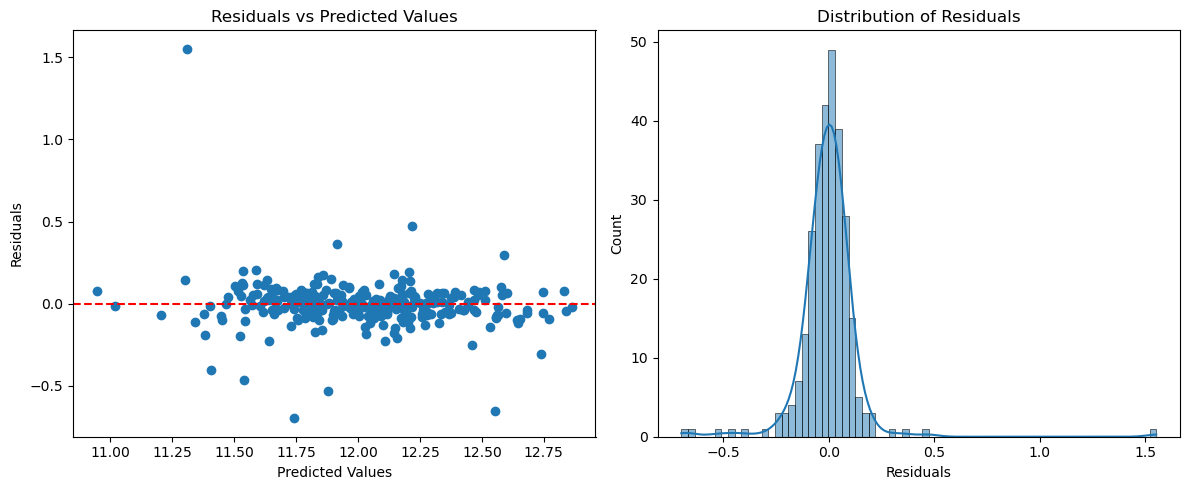

In [22]:

# Evaluate model
# Calculate R2 train and R2 Test
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

#Calculate Adjusted R2 train and Adjusted R2 Test
n_train = X_train.shape[0]
p_train = X_train.shape[1]
adjusted_r2_train = 1 - (1 - r2_train) * (n_train - 1) / (n_train - p_train - 1)

n_test = X_test.shape[0]
p_test = X_test.shape[1]
adjusted_r2_test = 1 - (1 - r2_test) * (n_test - 1) / (n_test - p_test - 1)


# Calculate RSS train and RSS test
rss_train = np.sum(np.square(y_train - y_pred_train))
rss_test = np.sum(np.square(y_test - y_pred_test))

# Calculate MSE train and MSE Test
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)

# Create a summary dataframe with all metrics calculated above
metrics_df = pd.DataFrame({
    'Metric': ['R2 Train', 'R2 Test', 'Adjusted R2 Train', 'Adjusted R2 Test', 'RSS Train', 'RSS Test', 'MSE Train', 'MSE Test'],
    'Value': [r2_train, r2_test, adjusted_r2_train, adjusted_r2_test, rss_train, rss_test, mse_train, mse_test]
})

print('\nModel Evaluation Metrics:')
print(metrics_df)

# Plotting residuals checking for homoscedasticity and distribution of residuals
residuals = y_test - y_pred_test
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_pred_test, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True)
plt.xlabel('Residuals')
plt.title('Distribution of Residuals')
plt.tight_layout()
plt.show()





In [23]:
# # Find the data for which we are observing outliers > 13 in predicted value
# outlier_data = X_test[y_pred_test > 13]

# # reverse scale the outlier_data using the same scaler
# outlier_data[cols_to_scale] = scaler.inverse_transform(outlier_data[cols_to_scale])
# print('\nOutlier Data (Predicted SalePrice > 13):')
# print(outlier_data)


#### The evaluation metric suggests overfitting 
- **Potential Model Complexity Issues**: The substantial difference between R2 and Adjusted R2, particularly on the test set, suggests the model likely has too many predictors relative to the sample size, or many of those predictors are irrelevant

- **Poor Generalization**: The large disparity between training and test metrics indicates the model has learned the noise and chance correlations in the training data rather than the true underlying relationship, failing to generalize to unseen data.


Lets try to resolve the model complexity problem using Lasso and Ridge Regression


RFE Model Evaluation Metrics:
                  Metric      Value
0           R2 Train RFE   0.931639
1            R2 Test RFE   0.810646
2  Adjusted R2 Train RFE   0.927863
3   Adjusted R2 Test RFE   0.760375
4          RSS Train RFE  10.686254
5           RSS Test RFE   6.903970
6          MSE Train RFE   0.009317
7           MSE Test RFE   0.024056
8         RMSE Train RFE   0.096523
9          RMSE Test RFE   0.155099


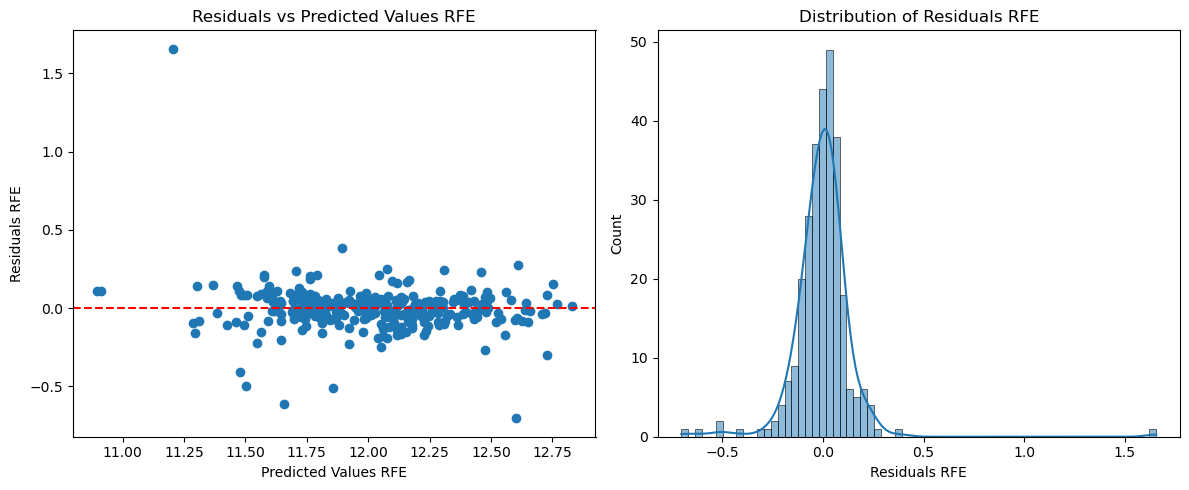

In [24]:
# Perform RFE to select top features
from sklearn.feature_selection import RFE
rfe = RFE(estimator=LinearRegression(), n_features_to_select=60)
rfe.fit(X_train, y_train)


# re-create linear regression model with selected features
X_train_rfe = X_train.loc[:, rfe.support_]
X_test_rfe = X_test.loc[:, rfe.support_]

lr_rfe = LinearRegression()
lr_rfe.fit(X_train_rfe, y_train)

# Evaluate RFE model
y_pred_train_rfe = lr_rfe.predict(X_train_rfe)
y_pred_test_rfe = lr_rfe.predict(X_test_rfe)

# Calculate R2 train and R2 Test for RFE model
r2_train_rfe = r2_score(y_train, y_pred_train_rfe)
r2_test_rfe = r2_score(y_test, y_pred_test_rfe)

#Calculate Adjusted R2 train and Adjusted R2 Test for RFE model
n_train_rfe = X_train_rfe.shape[0]
p_train_rfe = X_train_rfe.shape[1]
adjusted_r2_train_rfe = 1 - (1 - r2_train_rfe) * (n_train_rfe - 1) / (n_train_rfe - p_train_rfe - 1)
n_test_rfe = X_test_rfe.shape[0]
p_test_rfe = X_test_rfe.shape[1]
adjusted_r2_test_rfe = 1 - (1 - r2_test_rfe) * (n_test_rfe - 1) / (n_test_rfe - p_test_rfe - 1)

# Calculate RSS train and RSS test for RFE model
rss_train_rfe = np.sum(np.square(y_train - y_pred_train_rfe))
rss_test_rfe = np.sum(np.square(y_test - y_pred_test_rfe))

# Calculate MSE train and MSE Test for RFE model
mse_train_rfe = mean_squared_error(y_train, y_pred_train_rfe)
mse_test_rfe = mean_squared_error(y_test, y_pred_test_rfe)

# Calculate root mean squared error (RMSE) for RFE model
rmse_train_rfe = np.sqrt(mse_train_rfe)
rmse_test_rfe = np.sqrt(mse_test_rfe)

# Create a summary dataframe with all metrics calculated above for RFE model
metrics_rfe_df = pd.DataFrame({
    'Metric': ['R2 Train RFE', 'R2 Test RFE', 'Adjusted R2 Train RFE', 'Adjusted R2 Test RFE', 'RSS Train RFE', 'RSS Test RFE', 'MSE Train RFE', 'MSE Test RFE', 'RMSE Train RFE', 'RMSE Test RFE'],
    'Value': [r2_train_rfe, r2_test_rfe, adjusted_r2_train_rfe, adjusted_r2_test_rfe, rss_train_rfe, rss_test_rfe, mse_train_rfe, mse_test_rfe, rmse_train_rfe, rmse_test_rfe]
})

print('\nRFE Model Evaluation Metrics:')
print(metrics_rfe_df)

# Plotting residuals checking for homoscedasticity and distribution of residuals
residuals_rfe = y_test - y_pred_test_rfe
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_pred_test_rfe, residuals_rfe)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values RFE')
plt.ylabel('Residuals RFE')
plt.title('Residuals vs Predicted Values RFE')
plt.subplot(1, 2, 2)
sns.histplot(residuals_rfe, kde=True)
plt.xlabel('Residuals RFE')
plt.title('Distribution of Residuals RFE')
plt.tight_layout()
plt.show()

# Update X_train and X_test to use RFE selected features for further modeling
X_train = X_train_rfe
X_test = X_test_rfe


In [25]:
# Check VIF for X_train features
# Create a copy of X_train then iteratively for 3 iterations calculate VIF for all features remove top 3, print list of removed columns, retain OverallQual if present
from statsmodels.stats.outliers_influence import variance_inflation_factor
X_train_vif = X_train.copy()
removed_columns = []
for iteration in range(3):
    vif_data = pd.DataFrame()
    vif_data['Feature'] = X_train_vif.columns
    vif_data['VIF'] = [variance_inflation_factor(X_train_vif.values, i) for i in range(X_train_vif.shape[1])]
    max_vif = vif_data['VIF'].max()
    if max_vif > 10:
        feature_to_remove = vif_data.loc[vif_data['VIF'] == max_vif, 'Feature'].values[0]
        if feature_to_remove == 'OverallQual':
            # If OverallQual has highest VIF, remove the next highest
            vif_data_sorted = vif_data.sort_values(by='VIF', ascending=False)
            feature_to_remove = vif_data_sorted.iloc[1]['Feature']
        X_train_vif = X_train_vif.drop(columns=[feature_to_remove])
        removed_columns.append(feature_to_remove)
    else:
        break


print('\nColumns removed due to high VIF (>10):')
print(removed_columns)

# print length of removed columns
print('\nNumber of columns with high VIF (>10):', len(removed_columns))






Columns removed due to high VIF (>10):
['RoofMatl_CompShg', 'Street_Pave', 'GarageCond_TA']

Number of columns with high VIF (>10): 3


In [26]:
# On Using below logic and removing highly correlated features even linear regression starts giving better results


# # Re-create linear regression model after removing high VIF columns
# X_train_reduced = X_train.drop(columns=removed_columns)
# X_test_reduced = X_test.drop(columns=removed_columns)

# lr_reduced = LinearRegression()
# lr_reduced.fit(X_train_reduced, y_train)
# y_pred_train_reduced = lr_reduced.predict(X_train_reduced)
# y_pred_test_reduced = lr_reduced.predict(X_test_reduced)

# # Evaluate reduced model
# # Calculate R2 train and R2 Test
# r2_train_reduced = r2_score(y_train, y_pred_train_reduced)
# r2_test_reduced = r2_score(y_test, y_pred_test_reduced)

# #Calculate Adjusted R2 train and Adjusted R2 Test
# n_train_reduced = X_train_reduced.shape[0]
# p_train_reduced = X_train_reduced.shape[1]
# adjusted_r2_train_reduced = 1 - (1 - r2_train_reduced) * (n_train_reduced - 1) / (n_train_reduced - p_train_reduced - 1)
# n_test_reduced = X_test_reduced.shape[0]
# p_test_reduced = X_test_reduced.shape[1]
# adjusted_r2_test_reduced = 1 - (1 - r2_test_reduced) * (n_test_reduced - 1) / (n_test_reduced - p_test_reduced - 1)

# # Calculate RSS train and RSS test
# rss_train_reduced = np.sum(np.square(y_train - y_pred_train_reduced))
# rss_test_reduced = np.sum(np.square(y_test - y_pred_test_reduced))

# # Calculate MSE train and MSE Test
# mse_train_reduced = mean_squared_error(y_train, y_pred_train_reduced)
# mse_test_reduced = mean_squared_error(y_test, y_pred_test_reduced)

# # Calculate RMSE train and RMSE Test
# rmse_train_reduced = np.sqrt(mse_train_reduced)
# rmse_test_reduced = np.sqrt(mse_test_reduced)

# # Create a summary dataframe with all metrics calculated above for reduced model
# metrics_reduced_df = pd.DataFrame({
#     'Metric': ['R2 Train', 'R2 Test', 'Adjusted R2 Train', 'Adjusted R2 Test', 'RSS Train', 'RSS Test', 'MSE Train', 'MSE Test', 'RMSE Train', 'RMSE Test'],
#     'Value': [r2_train_reduced, r2_test_reduced, adjusted_r2_train_reduced, adjusted_r2_test_reduced, rss_train_reduced, rss_test_reduced, mse_train_reduced, mse_test_reduced, rmse_train_reduced, rmse_test_reduced]
# })

# print('\nReduced Model Evaluation Metrics:')
# print(metrics_reduced_df)

# # Plotting residuals checking for homoscedasticity and distribution of residuals for reduced model
# residuals_reduced = y_test - y_pred_test_reduced
# plt.figure(figsize=(12, 5))
# plt.subplot(1, 2, 1)
# plt.scatter(y_pred_test_reduced, residuals_reduced)
# plt.axhline(0, color='red', linestyle='--')
# plt.xlabel('Predicted Values')
# plt.ylabel('Residuals')
# plt.title('Residuals vs Predicted Values (Reduced Model)')
# plt.subplot(1, 2, 2)
# sns.histplot(residuals_reduced, kde=True)
# plt.xlabel('Residuals')
# plt.title('Distribution of Residuals (Reduced Model)')
# plt.tight_layout()
# plt.show()

# X_train = X_train_reduced
# X_test = X_test_reduced


### 5.b Using Ridge Regression

In [27]:
# list of alphas to tune - if value too high it will lead to underfitting, if it is too low, 
# it will not handle the overfitting
params = {'alpha': [ 0.1,0.25,0.3,0.35,0.4,0.425,0.45,0.475,0.5,0.52, 0.55, 0.6, 0.625, 0.65,0.75,1.0,1.25,1.5,1.75,1.85,
                    1.90,1.92,1.95,1.98,2.0,2.01,2.02,2.05,2.075,2.1,2.15,2.20,2.25,2.5,2.75,3.0, 3.25, 
                    3.5, 3.75, 4.0, 4.25, 4.5, 4.75, 5.0
                     ]}

ridge = Ridge()
folds = 5

# cross validation
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(estimator=ridge, param_grid=params, 
                           scoring='neg_mean_squared_error', cv=folds, return_train_score=True,
                        verbose = 1)

grid_search.fit(X_train, y_train)

print('\nBest alpha for Ridge Regression:', grid_search.best_params_)


Fitting 5 folds for each of 44 candidates, totalling 220 fits

Best alpha for Ridge Regression: {'alpha': 2.1}


In [28]:
# Best hyperparameter alpha
best_alpha = grid_search.best_params_['alpha']

ridge = Ridge(alpha=best_alpha)
ridge.fit(X_train, y_train)

print(ridge.coef_)

[ 0.47469782  0.55216086  0.2639111   0.37806978  0.27927034  0.88277426
  0.17424157  0.14987441  0.23284853  0.07646987  0.10235321  0.05481367
  0.11055208 -0.04699788  0.00318297  0.14525981 -0.12612685  0.0960942
  0.03493058  0.08052019  0.04508674  0.06011307 -0.39780515 -0.00991757
 -0.06159218 -0.01540949  0.07621589  0.03776389  0.14123435  0.07879267
  0.05376608  0.07785995  0.14616015  0.08360246  0.14442076  0.09104965
 -0.06346109 -0.13943474 -0.08467385 -0.13507802 -0.1121436  -0.06777444
 -0.12046074  0.02426236  0.04313259 -0.10865575  0.07178493 -0.04336653
 -0.05771341  0.00808936 -0.01406511 -0.05604062  0.06497044  0.04775125
 -0.04851568  0.1032104   0.04045366  0.06107524  0.06116598 -0.22078398]



Ridge Model Evaluation Metrics:
              Metric      Value
0           R2 Train   0.890843
1            R2 Test   0.863541
2  Adjusted R2 Train   0.884812
3   Adjusted R2 Test   0.827313
4          RSS Train  17.063621
5           RSS Test   4.975393
6          MSE Train   0.014877
7           MSE Test   0.017336
8         RMSE Train   0.121970
9          RMSE Test   0.131666


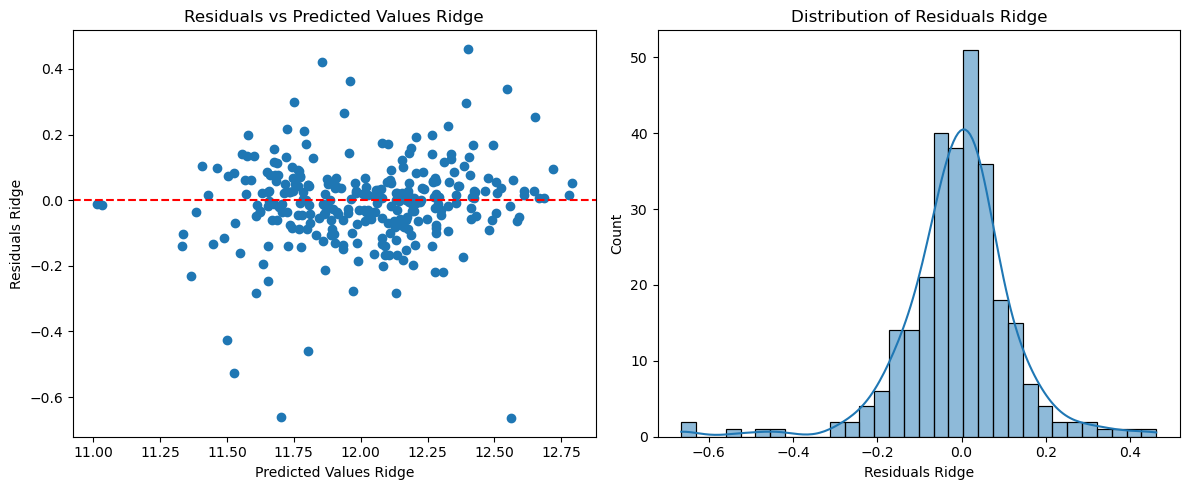

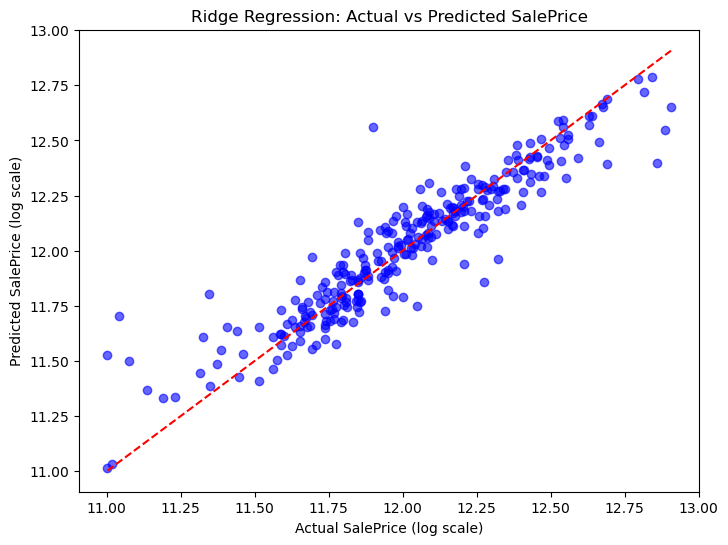

In [29]:
#Evaluate Ridge model

y_pred_train_ridge = ridge.predict(X_train)
y_pred_test_ridge = ridge.predict(X_test)

# Calculate R2 train and R2 Test
r2_train_ridge = r2_score(y_train, y_pred_train_ridge)
r2_test_ridge = r2_score(y_test, y_pred_test_ridge)

# Calculate Adjusted R2 train and Adjusted R2 Test
n_train = X_train.shape[0]
p_train = X_train.shape[1]
adjusted_r2_train_ridge = 1 - (1 - r2_train_ridge) * (n_train - 1) / (n_train - p_train - 1)

n_test = X_test.shape[0]
p_test = X_test.shape[1]
adjusted_r2_test_ridge = 1 - (1 - r2_test_ridge) * (n_test - 1) / (n_test - p_test - 1)

# Calculate RSS train and RSS test
rss_train_ridge = np.sum(np.square(y_train - y_pred_train_ridge))
rss_test_ridge = np.sum(np.square(y_test - y_pred_test_ridge))

# Calculate MSE train and MSE Test
mse_train_ridge = mean_squared_error(y_train, y_pred_train_ridge)
mse_test_ridge = mean_squared_error(y_test, y_pred_test_ridge)

# Calculate root mean squared error (RMSE) for train and test
rmse_train_ridge = np.sqrt(mse_train_ridge)
rmse_test_ridge = np.sqrt(mse_test_ridge)

# Create a summary dataframe with all metrics calculated above
metrics_ridge_df = pd.DataFrame({
    'Metric': ['R2 Train', 'R2 Test', 'Adjusted R2 Train', 'Adjusted R2 Test', 'RSS Train', 'RSS Test', 'MSE Train', 'MSE Test', 'RMSE Train', 'RMSE Test'],
    'Value': [r2_train_ridge, r2_test_ridge, adjusted_r2_train_ridge, adjusted_r2_test_ridge, rss_train_ridge, rss_test_ridge, mse_train_ridge, mse_test_ridge, rmse_train_ridge, rmse_test_ridge]
})

print('\nRidge Model Evaluation Metrics:')
print(metrics_ridge_df)

# Plotting residuals checking for homoscedasticity and distribution of residuals
residuals_ridge = y_test - y_pred_test_ridge
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_pred_test_ridge, residuals_ridge)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values Ridge')
plt.ylabel('Residuals Ridge')
plt.title('Residuals vs Predicted Values Ridge')
plt.subplot(1, 2, 2)
sns.histplot(residuals_ridge, kde=True)
plt.xlabel('Residuals Ridge')
plt.title('Distribution of Residuals Ridge')
plt.tight_layout()
plt.show()

# Generate the plot to show fit of the model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test_ridge, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Actual SalePrice (log scale)')
plt.ylabel('Predicted SalePrice (log scale)')
plt.title('Ridge Regression: Actual vs Predicted SalePrice')
plt.show()



### 5.c Use Lasso Regression

In [30]:
# Use Lasso Regression to see if we can get better results

# Perform Grid search to find good alpha value for Lasso Regression
from sklearn.model_selection import GridSearchCV

params = {'alpha': [0.000050,0.00006,0.000075,0.00008,0.000090, 0.000095, 0.000098, 0.0001,0.00034, 0.00035, 0.0003512, 0.0003525, 0.0003555, 0.0003575, 0.0003580, 0.0003590, 0.00036, 
                    0.0003612, 0.0003625, 0.0003655, 0.0003675, 0.0003685, 0.0003690, 0.00037, 0.0003712, 0.0003725, 0.0003755, 
                    0.0003775, 0.0003790, 0.0004, 0.00042, 0.00045, 0.0005, 0.00052, 0.00055,0.000575, 0.0006, 0.00065, 0.0007, 0.00075, 0.0008, 0.00085, 0.0009, 0.00095, 0.001,
                     0.005, 0.01, 0.05, 0.1, 0.5, 1.0
                    ]}

lasso = Lasso()

grid_search_lasso = GridSearchCV(estimator=lasso, param_grid=params, cv=5,return_train_score=True,
                        verbose = 1)
grid_search_lasso.fit(X_train, y_train)

best_alpha_lasso = grid_search_lasso.best_params_['alpha']
print(f"Best alpha for Lasso Regression: {best_alpha_lasso}")

lasso_best = Lasso(alpha=best_alpha_lasso)
lasso_best.fit(X_train, y_train)

Fitting 5 folds for each of 51 candidates, totalling 255 fits
Best alpha for Lasso Regression: 0.00075


Lasso(alpha=0.00075)


Lasso Model Evaluation Metrics:
              Metric      Value
0           R2 Train   0.883584
1            R2 Test   0.866745
2  Adjusted R2 Train   0.877152
3   Adjusted R2 Test   0.831367
4          RSS Train  18.198368
5           RSS Test   4.858582
6          MSE Train   0.015866
7           MSE Test   0.016929
8         RMSE Train   0.125961
9          RMSE Test   0.130111

Ridge RMSE Test in original scale: 23843.21689273029
Lasso RMSE Test in original scale: 23439.365060526117
Linear Regression RMSE Test in original scale: 27119.60067226791


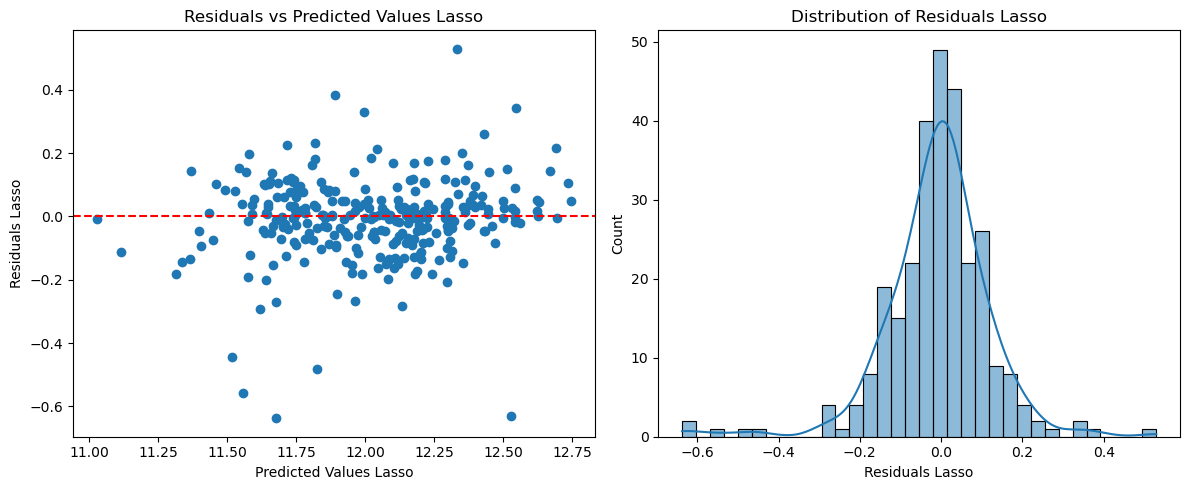

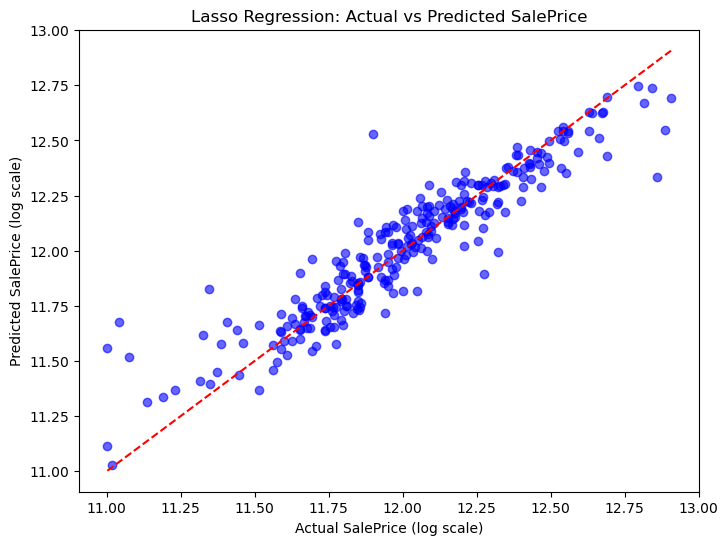

In [31]:
# Evaluate Lasso model

y_pred_train_lasso = lasso_best.predict(X_train)
y_pred_test_lasso = lasso_best.predict(X_test)

# Calculate R2 train and R2 Test
r2_train_lasso = r2_score(y_train, y_pred_train_lasso)
r2_test_lasso = r2_score(y_test, y_pred_test_lasso)

# Calculate Adjusted R2 train and Adjusted R2 Test
n_train = X_train.shape[0]
p_train = X_train.shape[1]
adjusted_r2_train_lasso = 1 - (1 - r2_train_lasso) * (n_train - 1) / (n_train - p_train - 1)
n_test = X_test.shape[0]
p_test = X_test.shape[1]
adjusted_r2_test_lasso = 1 - (1 - r2_test_lasso) * (n_test - 1) / (n_test - p_test - 1)

# Calculate RSS train and RSS test
rss_train_lasso = np.sum(np.square(y_train - y_pred_train_lasso))
rss_test_lasso = np.sum(np.square(y_test - y_pred_test_lasso))

# Calculate MSE train and MSE Test
mse_train_lasso = mean_squared_error(y_train, y_pred_train_lasso)
mse_test_lasso = mean_squared_error(y_test, y_pred_test_lasso)

# Calculate root mean squared error (RMSE) for train and test
rmse_train_lasso = np.sqrt(mse_train_lasso)
rmse_test_lasso = np.sqrt(mse_test_lasso)

# Create a summary dataframe with all metrics calculated above
metrics_lasso_df = pd.DataFrame({
    'Metric': ['R2 Train', 'R2 Test', 'Adjusted R2 Train', 'Adjusted R2 Test', 'RSS Train', 'RSS Test', 'MSE Train', 'MSE Test', 'RMSE Train', 'RMSE Test'],
    'Value': [r2_train_lasso, r2_test_lasso, adjusted_r2_train_lasso, adjusted_r2_test_lasso, rss_train_lasso, rss_test_lasso, mse_train_lasso, mse_test_lasso, rmse_train_lasso, rmse_test_lasso]
})  

print('\nLasso Model Evaluation Metrics:')
print(metrics_lasso_df)

# Print root mean sqaure error in original scale
# print(f"\nRidge RMSE Test in original scale: {rmse_test_ridge * (df['SalePrice'].max() - df['SalePrice'].min())}")
# print(f"Lasso RMSE Test in original scale: {rmse_test_lasso * (df['SalePrice'].max() - df['SalePrice'].min())}")
# print(f"Linear Regression RMSE Test in original scale: {np.sqrt(mse_test) * (df['SalePrice'].max() - df['SalePrice'].min())}")

#Print root mean square error using expm1 to revert log1p transformation
print(f"\nRidge RMSE Test in original scale: {np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_test_ridge)))}")
print(f"Lasso RMSE Test in original scale: {np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_test_lasso)))}")
print(f"Linear Regression RMSE Test in original scale: {np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_test)))}")

# Plotting residuals checking for homoscedasticity and distribution of residuals
residuals_lasso = y_test - y_pred_test_lasso
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_pred_test_lasso, residuals_lasso)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values Lasso')
plt.ylabel('Residuals Lasso')
plt.title('Residuals vs Predicted Values Lasso')
plt.subplot(1, 2, 2)
sns.histplot(residuals_lasso, kde=True)
plt.xlabel('Residuals Lasso')
plt.title('Distribution of Residuals Lasso')
plt.tight_layout()
plt.show()

# Generate the plot to show the fit of the model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test_lasso, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Actual SalePrice (log scale)')
plt.ylabel('Predicted SalePrice (log scale)')
plt.title('Lasso Regression: Actual vs Predicted SalePrice')
plt.show()


In [32]:
# Create a dataframe comparing coefficients of Linear regression reduced, Ridge and Lasso models
coefficients_df = pd.DataFrame({
    'Feature': X_train.columns,
    #'Linear_Regression_Coeff': lr_reduced.coef_,
    'Linear_Regression_Coeff': lr_rfe.coef_,
    'Ridge_Coeff': ridge.coef_,
    'Lasso_Coeff': lasso_best.coef_
})

# Print top n most significant feature of each model based on absolute coefficient value, print both absolute value and original value and sort by absolute value
n = 30
top_linear = coefficients_df.reindex(coefficients_df['Linear_Regression_Coeff'].abs().sort_values(ascending=False).index).head(n)
top_ridge = coefficients_df.reindex(coefficients_df['Ridge_Coeff'].abs().sort_values(ascending=False).index).head(n)
top_lasso = coefficients_df.reindex(coefficients_df['Lasso_Coeff'].abs().sort_values(ascending=False).index).head(n)


In [33]:


# Print count of non-zero coefficients in Linear regression model
non_zero_linear = (coefficients_df['Linear_Regression_Coeff'] != 0).sum()
print(f'\nTop {n}/({non_zero_linear}) Features by Linear Regression Coefficients:')
print(top_linear[['Feature', 'Linear_Regression_Coeff']])



Top 30/(60) Features by Linear Regression Coefficients:
                  Feature  Linear_Regression_Coeff
29       RoofMatl_Membran                 3.038129
30         RoofMatl_Metal                 2.956747
31          RoofMatl_Roll                 2.809493
34       RoofMatl_WdShngl                 2.787531
32       RoofMatl_Tar&Grv                 2.784594
28       RoofMatl_CompShg                 2.752936
33       RoofMatl_WdShake                 2.642757
22        Condition2_PosN                -1.655013
5               GrLivArea                 1.452103
4             TotalBsmtSF                 0.726473
0                 LotArea                 0.494597
3               YearBuilt                 0.467479
1             OverallQual                 0.415520
23        Condition2_RRAe                -0.398016
45         Functional_Sev                -0.376372
2             OverallCond                 0.324818
27         RoofStyle_Shed                 0.283119
6            BsmtFullBath

In [34]:

# Print count of non-zero coefficients in Ridge regression model
non_zero_ridge = (coefficients_df['Ridge_Coeff'] != 0).sum()
print(f'\nTop {n}/({non_zero_ridge}) Features by Ridge Regression Coefficients:')
print(top_ridge[['Feature', 'Ridge_Coeff']])



Top 30/(60) Features by Ridge Regression Coefficients:
                 Feature  Ridge_Coeff
5              GrLivArea     0.882774
1            OverallQual     0.552161
0                LotArea     0.474698
22       Condition2_PosN    -0.397805
3              YearBuilt     0.378070
4            TotalBsmtSF     0.279270
2            OverallCond     0.263911
8             GarageCars     0.232849
59          PoolArea_Yes    -0.220784
6           BsmtFullBath     0.174242
7             Fireplaces     0.149874
32      RoofMatl_Tar&Grv     0.146160
15  Neighborhood_Crawfor     0.145260
34      RoofMatl_WdShngl     0.144421
28      RoofMatl_CompShg     0.141234
37           BsmtQual_Fa    -0.139435
39           BsmtQual_TA    -0.135078
16  Neighborhood_MeadowV    -0.126127
42       Functional_Maj2    -0.120461
40          Heating_Grav    -0.112144
12           Street_Pave     0.110552
45        Functional_Sev    -0.108656
55          SaleType_New     0.103210
10           ScreenPorch     0.1

In [35]:

# Print count of non-zero coefficients in Lasso regression model
non_zero_lasso = (coefficients_df['Lasso_Coeff'] != 0).sum()
print(f'\nTop {n}/({non_zero_lasso}) Features by Lasso Regression Coefficients:')
print(top_lasso[['Feature', 'Lasso_Coeff']])



Top 30/(29) Features by Lasso Regression Coefficients:
                 Feature  Lasso_Coeff
5              GrLivArea     1.070884
1            OverallQual     0.598145
0                LotArea     0.480937
22       Condition2_PosN    -0.449192
3              YearBuilt     0.436690
2            OverallCond     0.277405
8             GarageCars     0.260245
6           BsmtFullBath     0.184398
4            TotalBsmtSF     0.161079
59          PoolArea_Yes    -0.149846
15  Neighborhood_Crawfor     0.127898
7             Fireplaces     0.120373
39           BsmtQual_TA    -0.089331
55          SaleType_New     0.086067
37           BsmtQual_Fa    -0.079651
35   Exterior1st_BrkFace     0.075899
16  Neighborhood_MeadowV    -0.071989
10           ScreenPorch     0.070905
19       Condition1_Norm     0.065515
38           BsmtQual_Gd    -0.056920
17  Neighborhood_StoneBr     0.056084
24       BldgType_Duplex    -0.048754
46        Functional_Typ     0.044714
58  SaleCondition_Normal     0.0

In [36]:



# Print the features where Lasso coefficient is zero
zero_coeff_features = coefficients_df[coefficients_df['Lasso_Coeff'] == 0]['Feature'].tolist()
print('\nFeatures with zero coefficient in Lasso Regression:')
print(zero_coeff_features)
print(f'Number of features with zero coefficient in Lasso Regression: {len(zero_coeff_features)}')

print('\nComparison of Coefficients:')
print(coefficients_df)


Features with zero coefficient in Lasso Regression:
['GarageArea', 'Street_Pave', 'Utilities_NoSeWa', 'LandSlope_Sev', 'Condition1_RRNe', 'Condition1_RRNn', 'Condition2_RRAe', 'HouseStyle_2.5Fin', 'RoofStyle_Mansard', 'RoofStyle_Shed', 'RoofMatl_Membran', 'RoofMatl_Metal', 'RoofMatl_Roll', 'RoofMatl_Tar&Grv', 'RoofMatl_WdShake', 'RoofMatl_WdShngl', 'Foundation_Wood', 'Heating_Grav', 'Electrical_FuseP', 'Functional_Maj2', 'Functional_Min1', 'Functional_Min2', 'Functional_Sev', 'GarageQual_Po', 'GarageCond_Fa', 'GarageCond_Gd', 'SaleType_CWD', 'SaleType_Con', 'SaleType_ConLI', 'SaleCondition_AdjLand', 'SaleCondition_Alloca']
Number of features with zero coefficient in Lasso Regression: 31

Comparison of Coefficients:
                  Feature  Linear_Regression_Coeff  Ridge_Coeff  Lasso_Coeff
0                 LotArea                 0.494597     0.474698     0.480937
1             OverallQual                 0.415520     0.552161     0.598145
2             OverallCond                 0

## Experimentation for Subjective Questions

- Double the values of alpha for both ridge and lasso and report the observations
- Report the most important predictor variables after change


Ridge Regression with best alpha (2.1) Evaluation Metrics:
R2 Test: 0.8635410049197876
Adjusted R2 Test: 0.8273129531285808
RSS Test: 4.975393049219461
MSE Test: 0.017335864282994638
RMSE Test: 0.131665729341369

Ridge Regression with double alpha (4.2) Evaluation Metrics:
R2 Test: 0.8563974518884293
Adjusted R2 Test: 0.818272881593322
RSS Test: 5.235852127626557
MSE Test: 0.018243387204273716
RMSE Test: 0.13506808358851366


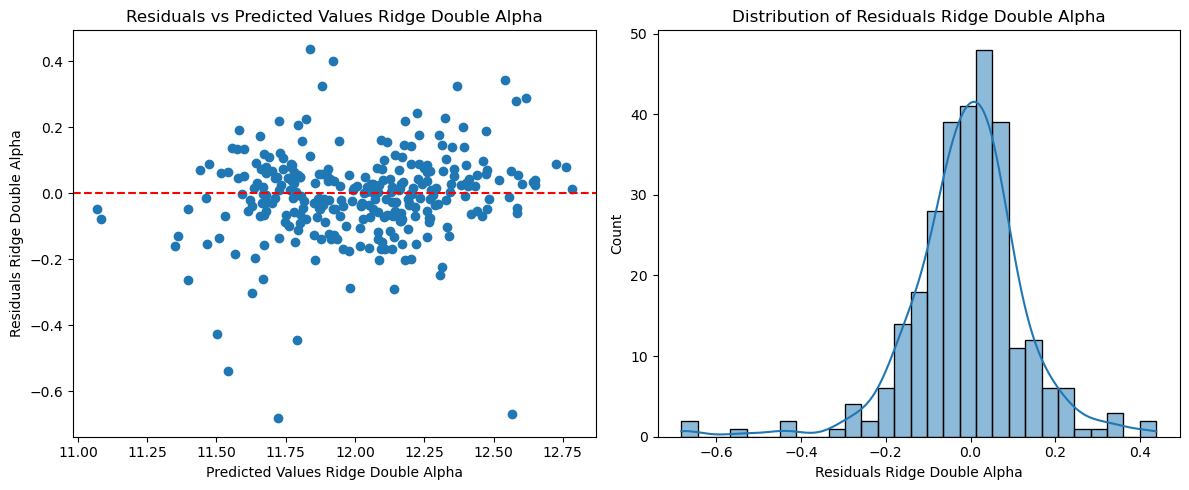

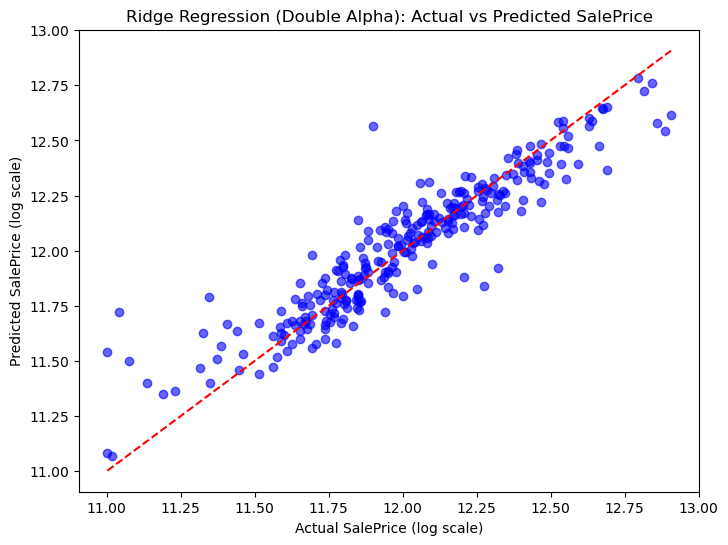

In [37]:
# Re-create ridge regression model using double the value of best alpha found earlier
ridge_double_alpha = Ridge(alpha=best_alpha * 2)
ridge_double_alpha.fit(X_train, y_train)

y_pred_test_ridge_double = ridge_double_alpha.predict(X_test)

#Evaluate the model

r2_test_ridge_double = r2_score(y_test, y_pred_test_ridge_double)
adjusted_r2_test_ridge_double = 1 - (1 - r2_test_ridge_double) * (n_test - 1) / (n_test - p_test - 1)
rss_test_ridge_double = np.sum(np.square(y_test - y_pred_test_ridge_double))
mse_test_ridge_double = mean_squared_error(y_test, y_pred_test_ridge_double)
rmse_test_ridge_double = np.sqrt(mse_test_ridge_double) 

# Print evaluation metrics before doubling alpha
print(f"\nRidge Regression with best alpha ({best_alpha}) Evaluation Metrics:")
print(f"R2 Test: {r2_test_ridge}")
print(f"Adjusted R2 Test: {adjusted_r2_test_ridge}")
print(f"RSS Test: {rss_test_ridge}")
print(f"MSE Test: {mse_test_ridge}")
print(f"RMSE Test: {rmse_test_ridge}")

#Print evaluation metrics after doubling alpha
print(f"\nRidge Regression with double alpha ({best_alpha * 2}) Evaluation Metrics:")
print(f"R2 Test: {r2_test_ridge_double}")
print(f"Adjusted R2 Test: {adjusted_r2_test_ridge_double}")
print(f"RSS Test: {rss_test_ridge_double}")
print(f"MSE Test: {mse_test_ridge_double}")
print(f"RMSE Test: {rmse_test_ridge_double}")

# Plotting residuals checking for homoscedasticity and distribution of residuals
residuals_ridge_double = y_test - y_pred_test_ridge_double
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_pred_test_ridge_double, residuals_ridge_double)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values Ridge Double Alpha')
plt.ylabel('Residuals Ridge Double Alpha')
plt.title('Residuals vs Predicted Values Ridge Double Alpha')
plt.subplot(1, 2, 2)
sns.histplot(residuals_ridge_double, kde=True)
plt.xlabel('Residuals Ridge Double Alpha')
plt.title('Distribution of Residuals Ridge Double Alpha')
plt.tight_layout()
plt.show()

# Generate the plot to show the fit of the model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test_ridge_double, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Actual SalePrice (log scale)')
plt.ylabel('Predicted SalePrice (log scale)')
plt.title('Ridge Regression (Double Alpha): Actual vs Predicted SalePrice')
plt.show()


In [38]:
# Print in a df the comparison of Ridge coefficients with best alpha and double alpha
ridge_coeff_comparison_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Ridge_Coeff_Best_Alpha': ridge.coef_,
    'Ridge_Coeff_Double_Alpha': ridge_double_alpha.coef_
})
print('\nRidge Coefficients Comparison (Best Alpha vs Double Alpha):')
print(ridge_coeff_comparison_df)


Ridge Coefficients Comparison (Best Alpha vs Double Alpha):
                  Feature  Ridge_Coeff_Best_Alpha  Ridge_Coeff_Double_Alpha
0                 LotArea                0.474698                  0.416452
1             OverallQual                0.552161                  0.547342
2             OverallCond                0.263911                  0.237248
3               YearBuilt                0.378070                  0.343058
4             TotalBsmtSF                0.279270                  0.239310
5               GrLivArea                0.882774                  0.717440
6            BsmtFullBath                0.174242                  0.164992
7              Fireplaces                0.149874                  0.178989
8              GarageCars                0.232849                  0.235197
9              GarageArea                0.076470                  0.119466
10            ScreenPorch                0.102353                  0.094517
11            MSZoning_FV  


Lasso Regression with best alpha (0.00075) Evaluation Metrics:
R2 Test: 0.8667447680441358
Adjusted R2 Test: 0.8313672728346143
RSS Test: 4.858581542796907
MSE Test: 0.016928855549815006
RMSE Test: 0.13011093555045636

Lasso Regression with double alpha (0.0015) Evaluation Metrics:
R2 Test: 0.8593966066462898
Adjusted R2 Test: 0.8220682721276057
RSS Test: 5.12650078932144
MSE Test: 0.017862372088228017
RMSE Test: 0.13365018551512758


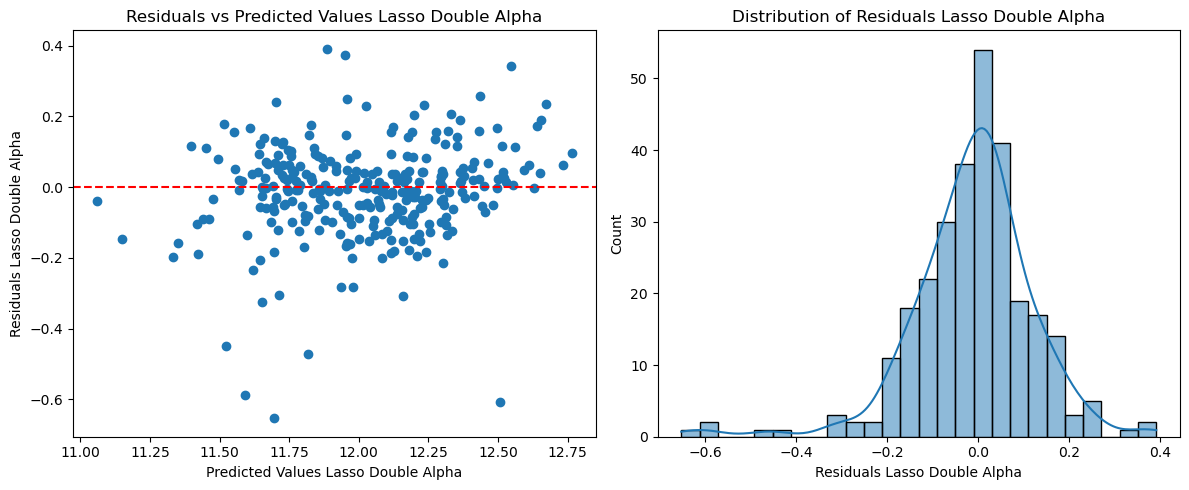

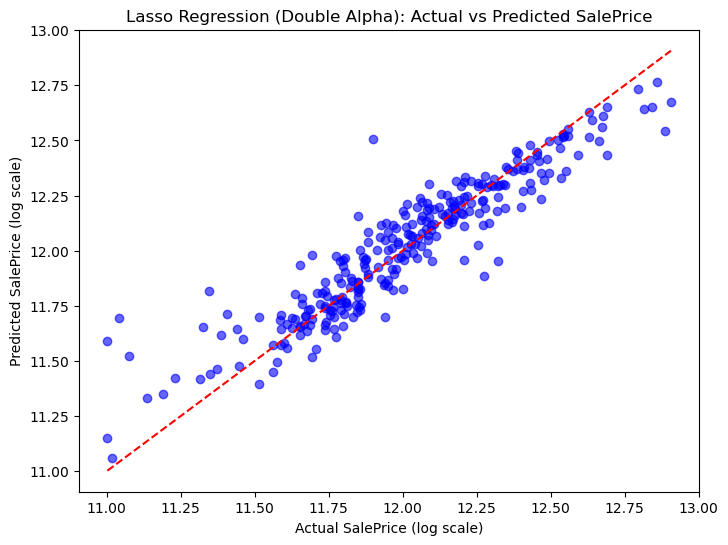

In [39]:
# Recreate Lasso regression model using double the value of best alpha found earlier
lasso_double_alpha = Lasso(alpha=best_alpha_lasso * 2)
lasso_double_alpha.fit(X_train, y_train)

y_pred_test_lasso_double = lasso_double_alpha.predict(X_test)

#Evaluate the model
r2_test_lasso_double = r2_score(y_test, y_pred_test_lasso_double)
adjusted_r2_test_lasso_double = 1 - (1 - r2_test_lasso_double) * (n_test - 1) / (n_test - p_test - 1)
rss_test_lasso_double = np.sum(np.square(y_test - y_pred_test_lasso_double))
mse_test_lasso_double = mean_squared_error(y_test, y_pred_test_lasso_double)
rmse_test_lasso_double = np.sqrt(mse_test_lasso_double)

# Print evaluation metrics before doubling alpha
print(f"\nLasso Regression with best alpha ({best_alpha_lasso}) Evaluation Metrics:")
print(f"R2 Test: {r2_test_lasso}")
print(f"Adjusted R2 Test: {adjusted_r2_test_lasso}")
print(f"RSS Test: {rss_test_lasso}")
print(f"MSE Test: {mse_test_lasso}")
print(f"RMSE Test: {rmse_test_lasso}")

#Print evaluation metrics after doubling alpha
print(f"\nLasso Regression with double alpha ({best_alpha_lasso * 2}) Evaluation Metrics:")
print(f"R2 Test: {r2_test_lasso_double}")
print(f"Adjusted R2 Test: {adjusted_r2_test_lasso_double}")
print(f"RSS Test: {rss_test_lasso_double}")
print(f"MSE Test: {mse_test_lasso_double}")
print(f"RMSE Test: {rmse_test_lasso_double}")

# Plotting residuals checking for homoscedasticity and distribution of residuals
residuals_lasso_double = y_test - y_pred_test_lasso_double
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_pred_test_lasso_double, residuals_lasso_double)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values Lasso Double Alpha')
plt.ylabel('Residuals Lasso Double Alpha')
plt.title('Residuals vs Predicted Values Lasso Double Alpha')
plt.subplot(1, 2, 2)
sns.histplot(residuals_lasso_double, kde=True)
plt.xlabel('Residuals Lasso Double Alpha')
plt.title('Distribution of Residuals Lasso Double Alpha')
plt.tight_layout()
plt.show()

# Generate the plot to show the fit of the model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test_lasso_double, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Actual SalePrice (log scale)')
plt.ylabel('Predicted SalePrice (log scale)')
plt.title('Lasso Regression (Double Alpha): Actual vs Predicted SalePrice')
plt.show()

In [40]:
# Number of features with zero coefficient in Lasso regression with double alpha
zero_coeff_features_double = np.sum(lasso_double_alpha.coef_ == 0)
print(f'\nNumber of features with zero coefficient in Lasso Regression (Double Alpha): {zero_coeff_features_double}')

# Print in a df the comparison of Lasso coefficients with best alpha and double alpha
lasso_coeff_comparison_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Lasso_Coeff_Best_Alpha': lasso_best.coef_,
    'Lasso_Coeff_Double_Alpha': lasso_double_alpha.coef_
})
print('\nLasso Coefficients Comparison (Best Alpha vs Double Alpha):')
print(lasso_coeff_comparison_df)


Number of features with zero coefficient in Lasso Regression (Double Alpha): 38

Lasso Coefficients Comparison (Best Alpha vs Double Alpha):
                  Feature  Lasso_Coeff_Best_Alpha  Lasso_Coeff_Double_Alpha
0                 LotArea                0.480937                  0.447885
1             OverallQual                0.598145                  0.692162
2             OverallCond                0.277405                  0.228873
3               YearBuilt                0.436690                  0.409560
4             TotalBsmtSF                0.161079                  0.011812
5               GrLivArea                1.070884                  0.923028
6            BsmtFullBath                0.184398                  0.175391
7              Fireplaces                0.120373                  0.140488
8              GarageCars                0.260245                  0.278431
9              GarageArea                0.000000                  0.000000
10            ScreenPo

## Re-create Lasso by removing top 5 predictor variables


Top 5 features with highest absolute coefficients in Lasso Regression:
['GrLivArea', 'OverallQual', 'LotArea', 'Condition2_PosN', 'YearBuilt']

Lasso Regression (Original Model) Evaluation Metrics:
R2 Test: 0.8667447680441358
Adjusted R2 Test: 0.8313672728346143
RSS Test: 4.858581542796907
MSE Test: 0.016928855549815006
RMSE Test: 0.13011093555045636

Lasso Regression (Reduced Model) Evaluation Metrics:
R2 Test: 0.7212714406314816
Adjusted R2 Test: 0.6549074979246916
RSS Test: 10.162643628482755
MSE Test: 0.03540990811318033
RMSE Test: 0.18817520589381675


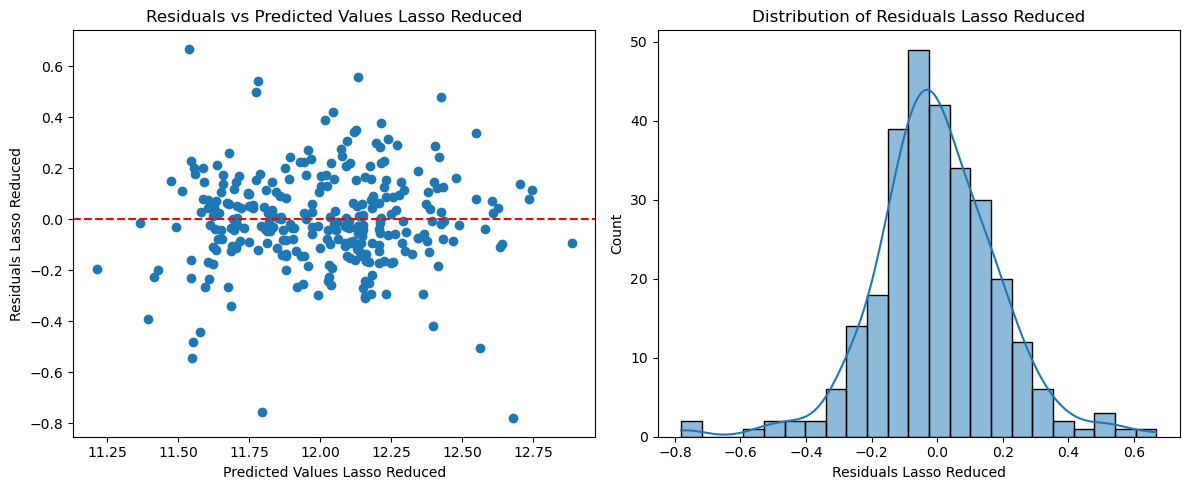

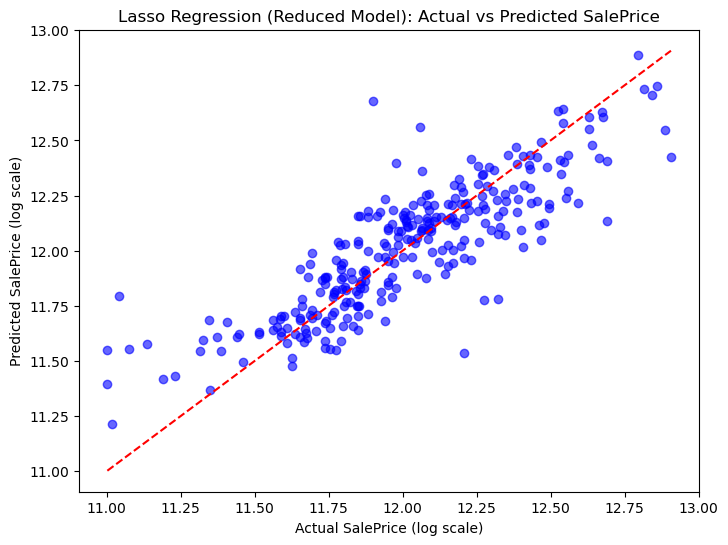


Top 5 features in Lasso Regression Reduced Model:
        Feature  Lasso_Coeff
1   TotalBsmtSF     0.897078
4    GarageCars     0.476580
32  BsmtQual_Fa    -0.445931
3    Fireplaces     0.390424
34  BsmtQual_TA    -0.359079
Number of non-zero features in Lasso Regression Reduced Model: 27


In [41]:
# Re-create Lasso regression model by removing top 5 features with highest absolute coefficients from best alpha model
top_5_features = coefficients_df.reindex(coefficients_df['Lasso_Coeff'].abs().sort_values(ascending=False).index).head(5)['Feature'].tolist()

#Print top 5 features
print('\nTop 5 features with highest absolute coefficients in Lasso Regression:')
print(top_5_features)

X_train_lasso_reduced = X_train.drop(columns=top_5_features)
X_test_lasso_reduced = X_test.drop(columns=top_5_features)

lasso_reduced = Lasso(alpha=best_alpha_lasso)
lasso_reduced.fit(X_train_lasso_reduced, y_train)

#Evaluate the reduced model
y_pred_test_lasso_reduced = lasso_reduced.predict(X_test_lasso_reduced)

r2_test_lasso_reduced = r2_score(y_test, y_pred_test_lasso_reduced)
adjusted_r2_test_lasso_reduced = 1 - (1 - r2_test_lasso_reduced) * (n_test - 1) / (n_test - (p_test - 5) - 1)
rss_test_lasso_reduced = np.sum(np.square(y_test - y_pred_test_lasso_reduced))
mse_test_lasso_reduced = mean_squared_error(y_test, y_pred_test_lasso_reduced)
rmse_test_lasso_reduced = np.sqrt(mse_test_lasso_reduced)

#Print evaluation metrics for original model
print(f"\nLasso Regression (Original Model) Evaluation Metrics:")
print(f"R2 Test: {r2_test_lasso}")
print(f"Adjusted R2 Test: {adjusted_r2_test_lasso}")
print(f"RSS Test: {rss_test_lasso}")
print(f"MSE Test: {mse_test_lasso}")
print(f"RMSE Test: {rmse_test_lasso}")

# Print evaluation metrics for reduced model
print(f"\nLasso Regression (Reduced Model) Evaluation Metrics:")
print(f"R2 Test: {r2_test_lasso_reduced}")
print(f"Adjusted R2 Test: {adjusted_r2_test_lasso_reduced}")
print(f"RSS Test: {rss_test_lasso_reduced}")
print(f"MSE Test: {mse_test_lasso_reduced}")
print(f"RMSE Test: {rmse_test_lasso_reduced}")

# Plotting residuals checking for homoscedasticity and distribution of residuals
residuals_lasso_reduced = y_test - y_pred_test_lasso_reduced
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_pred_test_lasso_reduced, residuals_lasso_reduced)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values Lasso Reduced')
plt.ylabel('Residuals Lasso Reduced')
plt.title('Residuals vs Predicted Values Lasso Reduced')
plt.subplot(1, 2, 2)
sns.histplot(residuals_lasso_reduced, kde=True)
plt.xlabel('Residuals Lasso Reduced')
plt.title('Distribution of Residuals Lasso Reduced')
plt.tight_layout()
plt.show()

# Generate the plot to show the fit of the reduced model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test_lasso_reduced, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Actual SalePrice (log scale)')
plt.ylabel('Predicted SalePrice (log scale)')
plt.title('Lasso Regression (Reduced Model): Actual vs Predicted SalePrice')
plt.show()

#Print top 5 features of new reduced model
coefficients_reduced_df = pd.DataFrame({
    'Feature': X_train_lasso_reduced.columns,
    'Lasso_Coeff': lasso_reduced.coef_
})
top_5_reduced = coefficients_reduced_df.reindex(coefficients_reduced_df['Lasso_Coeff'].abs().sort_values(ascending=False).index).head(5)
print('\nTop 5 features in Lasso Regression Reduced Model:')
print(top_5_reduced)



#Print number of non-zero features in reduced model
non_zero_lasso_reduced = (lasso_reduced.coef_ != 0).sum()
print(f'Number of non-zero features in Lasso Regression Reduced Model: {non_zero_lasso_reduced}')
